# 1. K-Nearest Neighbors Model

**load library**

In [ ]:
# data set
from sklearn.datasets import load_iris

import pandas as pd

import matplotlib.pyplot as plt

# split the trainning set and test set
from sklearn.model_selection import train_test_split

# standardization
from sklearn.preprocessing import StandardScaler
# normalization library
from sklearn.preprocessing import MinMaxScaler

# KNN API
from sklearn.neighbors import KNeighborsClassifier

# model evaluation
from sklearn.metrics import accuracy_score

**load data set**

In [ ]:
def load_data():
  iris_data = load_iris()

  print(iris_data.keys())

  print(iris_data.get('data')[:1])

  print(iris_data.get('DESCR'))

**visulization of the data set**

In [ ]:
def display_data():
  iris_data = load_iris()
  #print(iris_data)

  dataFrame = pd.DataFrame(iris_data['data'], columns=iris_data['feature_names'])

  dataFrame['label'] = iris_data['target']
  print(dataFrame)
  #print(dataFrame.describe()

  #plt.plot(dataFrame)

**split the data set**

In [ ]:
def split_train_test():
  data = load_iris()

  x_train, x_test, y_train, y_test = train_test_split(data['data'], data['target'], test_size=0.2, random_state=1)


  #print(x_train)

**evaluation of model**

1. estimator.score(test_x, test_y) (自动挡)这是模型对象（如 KNN 预测器）自带的一个快捷方法。

*   特点：你只需要把测试数据丢进去，它自己会在后台先运行 predict，然后根据模型类型自动选择评分标准（分类模型用 Accuracy，回归模型用 $R^2$）。
*   优点：代码极其简洁，不容易写错。


2. accuracy_score(test_y, estimator.predict(test_x)) (手动挡)
这是从 sklearn.metrics 模块中独立调用的一个函数。

*   特点：你需要手动完成两步：先让模型出预报（predict），然后把“标准答案”和“预报结果”一起交给这个函数对比。

*   优点：
      *   灵活性高：你可以随时把 accuracy_score 换成其他指标（比如 precision_score 或 recall_score），而 score() 只能返回默认指标。
      *   解耦：如果你想把预测结果拿出来先做一些处理（比如过滤掉一些低置信度的预测），必须用这种方式。


**entire code**

In [ ]:
def iris_case():
  # 1. load data
  iris_data = load_iris()
  #print(iris_data)


  # 2. preprocessing
  # split the data by 8:2 percentage
  x_train, x_test, y_train, y_test = train_test_split(iris_data['data'], iris_data['target'], test_size=0.2, random_state=2)


  # 3. feature engineering
  # feature extraction (choose the features which is relevant to the prediction)

  # feature preprocessing (standardization / normalization)
  # create standardization object
  transfer = StandardScaler()
  # standardize train and test features
  # fit_transform(): 	1.	fit(X_train)：计算训练集的均值、方差
  #                   2.	transform(X_train)：用这些值标准化训练集
  x_train = transfer.fit_transform(x_train)
  # transform(): 不重新算均值、方差,直接用训练集学到的参数
  # 在测试集上用 fit_transform(): 数据泄漏（Data Leakage）
  x_test = transfer.transform(x_test)


  # 4. model training
  # create model
  estimator = KNeighborsClassifier(n_neighbors=5)

  # train the model
  estimator.fit(x_train, y_train)


  # 5. model prediction
  # predict x_test
  y_pre = estimator.predict(x_test)

  print(y_pre)
  #print(estimator.predict_proba(x_test))

  # predict new data set
  # self-define test set
  my_data = [[7.0, 3.5, 1.3, 2.2]]
  # standardize my data set
  my_data = transfer.transform(my_data)
  # predict the new data set
  my_data_pre = estimator.predict(my_data)
  print(my_data_pre[0])
  print(f"this is: {iris_data['target_names'][my_data_pre[0]]}")

  # check the probability for each kinds
  my_data_pre_proba = estimator.predict_proba(my_data)
  print(f'(each categories)probability of my input data:{my_data_pre_proba}')


  # 6. model evaluation (模型预测对了多少)
  # method 1: directly score, using the features and labels of the training set
  correctness = estimator.score(x_train, y_train)
  print(f"correctness is: {correctness} (training set)")
  correctness = estimator.score(x_test, y_test)
  print(f"correctness is: {correctness} (testing set)")

  # method 2: based on labels of testing set and results of prediction
  correctness = accuracy_score(y_test, y_pre)
  print(f"correctness is: {correctness} (compare with testing and predicting label)")


if __name__ == '__main__':
  #load_data()
  #display_data()
  #split_train_test()
  iris_case()




[0 0 2 0 0 2 0 2 2 0 0 0 0 0 1 1 0 1 2 1 2 1 2 1 1 0 0 2 0 2]
1
this is: versicolor
(each categories)probability of my input data:[[0.  0.8 0.2]]
correctness is: 0.9583333333333334 (training set)
correctness is: 0.9666666666666667 (testing set)
correctness is: 0.9666666666666667 (compare with testing and predicting label)


**grid search and cross-validation**

In [ ]:
from sklearn.model_selection import GridSearchCV

def grid_search_CV():
  # 1. load date set
  iris_data = load_iris()

  # 2. processing
  # 切分训练集和测试集 （数据的特征集， 标签集， 测试集比例， 训练集比例， 随机种子）
  x_train, x_test, y_train, y_test = train_test_split(iris_data['data'], iris_data['target'], test_size=0.2, random_state=123)

  # 3. feature engineering （特征预处理  ->  标准化/归一化）
  transfer = StandardScaler()

  x_train = transfer.fit_transform(x_train)
  x_test = transfer.transform(x_test)

  # 4. model training
  estimator = KNeighborsClassifier()

  # 超参数可能出现的情况的字典
  param_dict = {'n_neighbors': [i for i in range(1, 11)]}

  # 创建GridSearchCV对象 -> 寻找最优超参（grid search + cross-validation）
  # estimator: 需要计算最优超参数的模型对象
  # 参数2: 该模型可能出现的超参数值
  # cv: 交叉验证的次数
  # 返回所寻找到超参数的模型对象
  estimator = GridSearchCV(estimator, param_dict, cv=4)

  # train the model
  estimator.fit(x_train, y_train)

  print(f"最优评分: {estimator.best_score_}")
  print(f"最优超参数组合: {estimator.best_params_}")
  print(f"最优估计器: {estimator.best_estimator_}")
  print(f"最优交叉验证结果: {estimator.cv_results_}")


grid_search_CV()

最优评分: 0.9666666666666668
最优超参数组合: {'n_neighbors': 8}
最优估计器: KNeighborsClassifier(n_neighbors=8)
最优交叉验证结果: {'mean_fit_time': array([0.00143868, 0.00098825, 0.00098294, 0.00097167, 0.00097644,
       0.00096762, 0.00110334, 0.0010848 , 0.00098556, 0.00099701]), 'std_fit_time': array([5.79204249e-04, 1.61958006e-05, 1.35577968e-05, 1.03300198e-05,
       1.38370100e-05, 1.06443950e-05, 9.46873579e-05, 9.44894369e-05,
       9.04322488e-06, 1.19475723e-05]), 'mean_score_time': array([0.002572  , 0.00230992, 0.00224316, 0.00224018, 0.00226343,
       0.00223053, 0.00310814, 0.00240344, 0.0023514 , 0.00231725]), 'std_score_time': array([2.60894827e-04, 7.71551219e-05, 2.37376199e-05, 3.28044385e-05,
       3.75134417e-05, 1.95463252e-05, 1.12685380e-03, 1.01521304e-04,
       9.27651274e-05, 2.31998399e-05]), 'param_n_neighbors': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
             mask=[False, False, False, False, False, False, False, False,
                   False, False],
    

## **1.2 Handwritten Digit Recognition by KNN**

MNIST 数据集：

数据规模： 70,000 个样本。

图像大小： $28 \times 28$ 像素。

特点： 需要联网下载，且由于数据量较大，训练速度会慢很多。

**导入 library**

In [ ]:
from sklearn.datasets import fetch_openml

# 本地内置的 load_digits (最快、最稳)
from sklearn.datasets import load_digits

import matplotlib.pyplot as plt

from collections import Counter

# 保存训练好的模型
import joblib

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

import numpy as np


**读取数据集**

In [ ]:
# 注意：第一次运行需要联网下载，大约几十MB
# mnist = fetch_openml('mnist_784', as_frame=False, parser='auto')

# 直接加载，无需网络
digits = load_digits()

# 提取特征列 和 标签列
data_x = digits['data']
data_y = digits['target']

**统计标签的分布情况**

In [ ]:
print(f"标签分布情况：{Counter(data_y)}")
print(f"标签分布情况：{Counter(data_y.tolist())}")

标签分布情况：Counter({np.int64(3): 183, np.int64(1): 182, np.int64(5): 182, np.int64(4): 181, np.int64(6): 181, np.int64(9): 180, np.int64(7): 179, np.int64(0): 178, np.int64(2): 177, np.int64(8): 174})
标签分布情况：Counter({3: 183, 1: 182, 5: 182, 4: 181, 6: 181, 9: 180, 7: 179, 0: 178, 2: 177, 8: 174})


**显示dataset中的某个图片**

In [ ]:
def show_digit(index):
  if index < 0 or index > len(data_x):
    print("parameter is out of index")
    return

  print(f"this image is {data_y[index]}")

  # 将 flattening 的 一维数组 reshape 为 (8, 8)
  x = data_x[index].reshape(8, 8)

  # paint image
  plt.imshow(x, cmap='gray')
  plt.axis('off')
  plt.show()

**训练模型并保存**

保存模型: joblib库

joblib.dump(model object, filename)

In [ ]:
def train_test_model(x, y):
  # normalization
  x /= 255

  # split dataset
  # stratify：按照y的分布分割，避免某类标签过于集中于训练集或者测试集
  train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, stratify=y, random_state=123)

  estimator = KNeighborsClassifier(n_neighbors=5)

  estimator.fit(train_x, train_y)

  # evaluation
  print(f"accuracy: {estimator.score(test_x, test_y)}")
  print(f"accuracy: {accuracy_score(test_y, estimator.predict(test_x))}")

  # save model
  joblib.dump(estimator, "./handwrittenDigitsRecognition.pkl")



**使用已经保存的模型进行预测**

In [ ]:
def use_model():
  # load data
  x = plt.imread('./demo.png') # read the image file
  #print(x[:, :, :3])

  # 1. 均值转灰度 (变为 0-1 之间的浮点数)
  x_gray = np.mean(x[:, :, :3], axis=2)

  # 2. 反转：1 变成 0，0 变成 1
  x_inverted = 1.0 - x_gray

  # 3. 放大到 0-16 范围
  x_final = x_inverted * 16

  # load model which was trained
  estimator = joblib.load("./handwrittenDigitsRecognition.pkl")

  # reshape the x
  # x.reshape(1, 8 * 8) 等价于 x.reshape(1, -1)
  x_reshaped = x_final.reshape(1, 8 * 8)

  # normalization
  x_reshaped /= 255

  # prediction
  predicted_y = estimator.predict(x_reshaped)

  print(f"predicted value is: {predicted_y}")


In [ ]:
#show_digit(123)
#train_test_model(data_x, data_y)
use_model()

predicted value is: [4]


## **1.3 Conclusion of KNN**

在使用 K-近邻算法（KNN） 时，改变 random_state（随机种子）会导致最优超参数 n_neighbors 发生变化，这主要由以下几个核心原因造成的：

1. 数据分布的“运气”成分当你改变随机种子时，train_test_split 会重新洗牌并切分数据。训练集变了： KNN 是一个极其依赖于“邻居”的算法。如果某个随机种子将一些“离群点”（Outliers）分到了训练集，而另一个种子将它们分到了测试集，模型的决策边界就会发生剧烈抖动。代表性差异： 在数据量较小（如 Iris 数据集仅 150 条）的情况下，微小的切分差异会导致某些类别的特征分布在训练集和测试集中不完全一致。

2. KNN 的“局部敏感性”KNN 是一种**懒惰学习（Lazy Learning）**算法，它没有全局模型，完全依赖于局部数据的空间分布：如果测试集中的某个点刚好落在训练集两个类别的交界处，n_neighbors=3 可能刚好选中了正确的邻居，而 n_neighbors=5 可能会因为包含了更多稍远一点的异类点而导致预测错误。这种“局部对峙”的情况会随着训练集样本的微调而改变，从而影响最优的 $k$ 值。

3. 过拟合与欠拟合的边界移动$k$ 值的选择本质上是在平衡偏差（Bias）和方差（Variance）：较小的 $k$（如 1 或 3）： 模型非常敏感，容易受到噪声影响（高方差）。较大的 $k$（如 15 或 20）： 模型过于平滑，容易忽略局部细节（高偏差）。由于每次随机切分出的测试集难度不同，有时一个“敏感”的模型（小 $k$）表现更好，有时一个“稳健”的模型（大 $k$）表现更好。

如何解决这个问题？如果你发现最优参数随种子乱跳，说明你的评价结果不可靠。为了获得更稳健的 n_neighbors，建议采用以下方法：

使用交叉验证（Cross-Validation）：不要只依赖一次 train_test_split。使用 GridSearchCV 配合 $K$-Fold 交叉验证。它会将数据切成 $n$ 份，轮流做训练和验证，最后取平均分。这能极大抵消随机切分带来的干扰.
增大样本量： 样本量越大，随机切分带来的统计偏差就越小。

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {'n_neighbors': range(1, 31)}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5) # 5折交叉验证
grid.fit(iris_data['data'], iris_data['target'])
print(grid.best_params_)

# 2. Linear Regression Model

## **Concepts**

**Definition**

利用回归方程（函数）对一个或者多个自变量（特征值）和因变量（目标值）之间的关系进行建模的一种分析方式

**Formula**

一元线性回归数学公式：
$$y = wx + b$$

多元线性回归数学公式：
$$h(w) = w_1x_1 + w_2x_2 + w_3x_3 + \dots + w_nx_n + b = \mathbf{W}^T\mathbf{X} + b$$


*   $w$ : 权重 (决定直线的斜率（自变量对结果的影响程度）)
*   $W$ : 一维列向量
*   $Wᵀ$ : 一维行向量 ([$w1, w2, ..., wn$])
*   $b$ : 偏置 (决定直线在 y 轴的截距（基础分/保底值）)
*   $x$ : 特征 (输入的数据（如：面积、工作年限）)
*   $\hat{y}$ : 预测值 (模型算出来的结果)



**线性回归模型求解**

公式中，**$x$（特征值）** 是已知的，所以求解线性回归模型就是要计算出 **权重 $w$** 和 **偏置$b$**

**API**

In [ ]:
from sklearn.linear_model import LinearRegression

from sklearn.metrics import accuracy_score

**Simple case**

In [ ]:
# 1. get dataset
x_train = [[160], [166], [172], [174], [180]]
y_train = [56.3, 60.6, 65.1, 68.5, 75]
x_test = [[176]]

# 2. preprocessing
# pass

# 3. feature engineering
# pass

# 4. model training
estimator = LinearRegression()
estimator.fit(x_train, y_train)

LinearRegression()

**查看 权重(weight) 与 偏置(bias)**

通过模型对象的:


*   **coef_** 属性：查看权重/斜率
*   **intercept_** 属性: 截距/偏置


In [ ]:
print(f"weight is: {estimator.coef_}")
print(f"bias is: {estimator.intercept_}")

weight is: [0.92942177]
bias is: -93.27346938775517


In [ ]:
# 5. model prediction
y_predicted = estimator.predict(x_test)
print(f"predicted result: {y_predicted}")

# 6. model evaluation
# accuracy_score()
#print(f"model accuracy: {estimator.score}")



predicted result: [70.3047619]


## **损失函数 (Loss Function)**

**最小二乘法**

最小二乘是一种思想，它的目标是让 MSE 变小。

* 定义：它的核心思想是——为了找到最好的模型，让所有误差的平方和最小。
* 场景：当你决定使用 $w = (X^T X)^{-1} X^T y$ 这个公式，或者使用 MSE 作为损失函数去优化时，你就在使用“最小二乘法”。

**损失函数分类**

1. 均方误差 (MSE - Mean Squared Error)
$$J(w) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2 = \frac{1}{m} \|Xw - y\|_2^2$$
特点：
    * 处处可导：是一个平滑的凸函数（碗状），非常适合梯度下降，收敛快。
    * 对异常值敏感：这是它的双刃剑。因为误差被平方了，如果有一个样本预测偏得很远（异常值），它的惩罚力度会变得超级大，导致模型为了迎合这一个“坏点”，而牺牲了对大多数正常点的预测准确度。

2. 平均绝对误差 L1 Loss (Mean Absolute Error, MAE)
$$J(w) = \frac{1}{m} \sum_{i=1}^{m} |y_i - \hat{y}_i| = \frac{1}{m} \|Xw - y\|_1$$
特点：
    * 对异常值鲁棒：误差不再被平方放大，所以模型不会被个别离群点带偏。
    * 0点不可导：函数图像是一个“V”字形，在底部尖端（误差为0处）没有导数。这对梯度下降算法是一个挑战（需要用次梯度 sub-gradient 处理），且在接近极小值时震荡，不容易收敛到精确的 0。

3. 均方根误差 (RMSE - Root Mean Squared Error)
$$J(w) = \sqrt{MSE} = \sqrt{\frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2} = \sqrt{\frac{1}{m} \|Xw - y\|_2^2}$$
特点：
    * RMSE 是给人看的，它让误差的单位回到正常世界。
    * 例子：预测房价。MSE 是 50“平方万元”，开根号后 RMSE $\approx 7.07$ 万元。这就很好理解了：“我的模型预测房价，平均误差在 7 万元左右。”
    * 最常用的评估指标（Report Metric），写在论文或报告里

4. 正则化损失 (Regularization)

在 MSE 后面加了一个“尾巴”（惩罚项）。是解决 $X^T X$ 不可逆问题的核心手段。
      
* A. Ridge Regression (岭回归 - L2 正则化)
$$J(w) = \text{MSE} + \lambda \sum w_j^2$$
作用：强行让 $w$ 的数值变小。从数学上讲，它给 $X^T X$ 的对角线加上了数字，使其一定可逆。
* Lasso Regression (套索回归 - L1 正则化)
$$J(w) = \text{MSE} + \lambda \sum |w_j|$$
作用：它非常激进，会让很多不重要的特征权重 $w_j$ 直接变成 0。这相当于自动帮你做了特征选择（Feature Selection）。

**误差(Error)**

    e = ŷ - y   (误差 = 预测值 - 真实值)
    
其中：
*   **e**: error 误差
*   **ŷ**: estimate / predicted value 估计值 或 预测值
*   **y**: ground truth / target 真实值、实际观测到的结果

**误差的作用：**

反馈方向和偏移特征（反馈 **当前预测值** 是比 **真实值** **大了还是小了**）




**损失函数**

用于描述 每个样本点 和 其预测值 之间的关系

让损失函数最小，即让误差和最小，线性回归的效率和评估就越高

**误差计算问题**

如果直接使用 $y - \hat{y}$，可能会产生负数，这会导致以下两个严重的问题：


1.   正负抵消现象（最致命）： 假设你有两个预测点：第一个点：预测比真实值多了 10（误差 = $+10$）第二个点：预测比真实值少了 10（误差 = $-10$）如果你直接把它们相加：$10 + (-10) = 0$。结果： 算出来的总误差是 $0$。模型会误以为自己预测得“完美无缺”，但实际上它在两个点上都错得很离谱。

2.   无法定义“最小化”目标： 在优化模型时，我们的目标是让误差“越小越好”。如果误差可以是负数，那么 $-100$ 比 $0$ 更小。如果我们追求最小值，模型会倾向于让误差变成一个巨大的负数（比如预测值比真实值小得多），而不是趋向于 $0$。


**解决误差出现正负值的 solutions**

可以采用 **绝对值** 和 **平方** 来杜绝负数的出现

1.   取绝对值 (L1 Loss / MAE)： 平均绝对误差 (Mean Absolute Error)
      *   公式：
  $|y - \hat{y}|$
      *   数学表达：$$\text{MAE} = \frac{1}{n} \sum_{i=0}^{n} |y_i - \hat{y}_i|$$
      *   优点： 对异常值（Outliers）更鲁棒。
      *   缺点： 计算导数麻烦，中心点不可导。

2.   平方处理 (L2 Loss / MSE): 均方误差 (Mean Square Error)
      *   公式：
  $(y - \hat{y})^2$
      *   数学表达：
  $$\text{MSE} = \frac{1}{n} \sum_{i=0}^{n} (y_i - \hat{y}_i)^2$$
      *   优点1： 负号消失了，且因为平方的特性，大误差被放大了
      *   优点2： 数学性质好，收敛快。
      *   缺点： 容易受极端异常值干扰。


**损失函数 / 代价函数**

公式：
$$J(w, b) = \frac{1}{n} \sum_{i=1}^{n} (h(x_i) - y_i)^2$$


*   $h$：代表 Hypothesis（假设）。之所以叫“假设”，是因为在模型训练完成之前，我们只是“假设”这个函数能代表输入和输出之间的关系。
*   $x_i$：代表第 $i$ 个输入数据（特征）。比如预测房价时，$x_i$ 可能是第 $i$ 套房子的面积。
*   $h(x_i)$：代表模型对第 $i$ 个数据的预测结果

**因此：**
$$h(x_i) = \hat{y}_i$$


这种写法强调的是过程（函数关系）。它提醒你，预测值是通过一个函数 $h$ 计算出来的。因为 $h(x) = wx + b$，所以这个公式隐含了：你想让代价 $J$ 变小，就得去调整 $h$ 里面的参数 $w$ 和 $b$。


$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
这种写法强调的是结果。它直截了当地告诉你：这是“真实值”和“预测值”的差距。它不关心预测值是怎么来的，只关心它准不准。

所以以上两种写法都是等价的，即：
$$\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = MSE = J(w, b) = \frac{1}{n} \sum_{i=1}^{n} (h(x_i) - y_i)^2$$


**它们什么时候互换?**

*   当你评估模型好坏（比如在 Colab 里看准确率）时，大家习惯用 $\hat{y}$。
*   当你训练/优化模型（比如求导、算梯度）时，大家必须写成 $h(x)$，因为你需要明确知道自变量是谁。


**累计求和前的 $\frac{1}{n}$ 解释**

乘以 $\frac{1}{n}$ 是为了归一化。 它让损失函数只取决于模型的“预测质量”，而与“计算了多少个样本”无关。

1. 学习率的稳定性（与样本量解耦）

如果你直接计算总损失 $\sum L_i$，那么损失值的大小会随着样本数 $n$ 的增加而线性增长。

* 不加 $\frac{1}{n}$： 当你有 10 个样本时，梯度可能比较小；当你增加到 1000 个样本时，梯度会突然放大 100 倍。这意味着你必须根据数据量的大小，不断手动调整学习率（Learning Rate）。
* 加 $\frac{1}{n}$： 损失函数变成了期望值。无论你的 Batch Size 是 32 还是 256，梯度的量级始终保持在同一个水平线上，使得一套超参数（如学习率）在不同规模的数据上更具通用性。

2. 统计学意义：期望风险最小化

在统计学中，我们通常希望最小化的是期望风险（Expected Risk）。由于我们无法获得真实世界的全部数据，只能通过手头的样本进行经验风险最小化（Empirical Risk Minimization, ERM）。
$$J(\theta) = \frac{1}{n} \sum_{i=1}^{n} L(f(x_i; \theta), y_i)$$
这里的 $\frac{1}{n} \sum$ 本质上是对真实分布的一种无偏估计。乘以 $\frac{1}{n}$ 使得我们的优化目标是在“平均意义”下做得最好，而不是单纯追求在当前这一堆数据上累加值最小。

3. 便于不同 Batch Size 的比较

在训练过程中，我们经常使用小批量随机梯度下降（Mini-batch SGD）。如果没有 $\frac{1}{n}$，一个含有 64 个样本的 Batch 产生的更新量会比含有 32 个样本的大得多。有了 $\frac{1}{n}$，我们可以直观地观察 Loss 曲线。无论 Batch 大小如何，Loss 值的范围是稳定的（比如都在 0 到 1 之间），这极大地方便了监控模型的收敛情况。

**为何常用MSE而不是MAE**

**1.   数学上的“顺滑”：可导性**

这是最重要的原因。机器学习训练通常使用梯度下降法，这需要对损失函数求导（找斜率）。

**平方差 ($x^2$)**： 它的图像是一条平滑的抛物线。在任何地方都有导数（斜率），而且越接近零点，斜率越小。这让模型在接近最优解时能自动“减速”，平稳收敛。

**绝对值** (**|x|**)： 它的图像是一个 “V” 字形。在最底部的尖角处（即误差为 0 的地方）是不可导的。这会导致模型在优化的最后阶段可能在最小值附近“反复横跳”，很难停在最精确的一点。

**2.   惩罚力度：对“大错”零容忍**
    
平方运算会放大较大的误差，从而强迫模型去关注那些错得离谱的数据点。

例如：
如果误差是 0.1，平方后是 0.01（变小了，模型觉得还能接受）。
如果误差是 10，平方后是 100（巨大，模型会感到“巨大的痛苦”，从而拼命去修正这个大错）。
    
结论： 平方差会让模型更倾向于把所有点的误差都控制在一个较小的范围内，而不是容忍几个巨大的错误。

**3.   统计学背景：正态分布**

从概率论的角度来看，如果我们假设数据的噪声符合**正态分布（高斯分布）**，那么通过数学推导（极大似然估计），最合理的损失函数形式恰好就是**平方差**。


**最小二乘法 (Ordinary Least Squares, OLS)**

本质是：
通过数学手段（通常是求导），去寻找一组参数（比如直线的斜率 $w$ 和截距 $b$），使得下面的 “误差平方和”达到最小。

**误差平方和	SSE** (Sum of Squared Errors)，在统计学、计量经济学、回归分析语境下也称作残差平方和	RSS (Residual Sum of Squares)
$$SSE = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$


## **线性回归模型的损失函数**

**描述**

多元线性回归最常用的损失函数是均方误差 (**MSE**)，它衡量了 $n$ 个样本的预测值与真实值之间的平均平方距离：
$$J(w, b) = \frac{1}{2n} \sum_{i=1}^{n} (\hat{y}^{(i)} - y^{(i)})^2$$

第i个样本的预测值：
$$\hat{y}^{(i)} = w_1x_1 + w_2x_2 + ... + w_kx_k + b = \sum_{j=1}^{k}w_jx_j + b $$

将预测公式代入，得到展开式：$$J(w, b) = \frac{1}{2n} \sum_{i=1}^{n} \left( \sum_{j=1}^{k} w_j x_j^{(i)} + b - y^{(i)} \right)^2$$

**使得损失函数最小的解决办法：**

*   正规方程法： 求解方程（求导、求偏导）
*   梯度下降法： 利用梯度逐步逼近最优解



**线性回归模型的损失函数 $J(\theta)$**

$$J(\theta) = \frac{1}{2n} \sum_{i=1}^{n} (h_\theta(x^{(i)}) - y^{(i)})^2 = \frac{1}{2n} \sum_{i=1}^{n} (\theta_0 + \sum_{j=1}^{k} \theta_j x_j - y_i)$$

**其中：**
* $\theta$（Theta）是一个集体名词。它并不代表某一个特定的数字，而是代表了模型中**所有需要学习的参数的集合**
* 在线性回归的语境下： $\theta$ 通常包含了两个部分：**权重（Weights）**和 **偏置（Bias）**
* 带参数的模型：$h_\theta(x) = \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_k x_k + \theta_0$  （$K + 1$ 个 $\theta$ ）
* $h_\theta(x^{(i)}) = \theta_0 + \theta_1x_1^{(i)} + \theta_2x_2^{(i)} + \dots + \theta_kx_k^{(i)} = \theta_0 + \sum_{i=1}^{k} \theta_i x_i$

**理解：**

你可以把 $\theta$ 想象成一个收音机的调音旋钮：
* 每一个特征对应一个旋钮。
* $\theta$ 就是这一排旋钮的总称。
* 你旋转旋钮（调整参数）的过程，就是在寻找能让音质最清晰（损失函数最小）的那个位置。

$\theta$ 是模型的“核心配置”。当你训练完一个模型并说“我拿到了模型文件”时，本质上你拿到的就是那一串被优化好的 $\theta$ 数值。

## **最小化损失函数**


1.   正规方程法 (Normal Equation)
2.   梯度下降法 (Gradient Descent)



**正规方程 (Normal Equation)**

**损失函数转成矩阵方式**
$$J(w) = \sum_{i=1}^{m} \left( \sum_{j=1}^{n} X_{ij} w_j - y_i \right)^2 = \| Xw - y \|_2^2 = (Xw - y)^T (Xw - y)$$
其中：
* $\|x\|_2^2 = x^T x = x_1^2 + x_2^2 + \dots + x_n^2$
* $X$： 一个 $m \times n$ 的二维矩阵，通常被称为 设计矩阵 (Design Matrix)，或者更通俗地说“特征矩阵” (Feature Matrix)。它包含了你所有的训练数据（输入数据）。$m$ (行数) = 样本数量 (Number of Samples)代表你有多少条数据。$n$ (列数) = 特征数量 (Number of Features)代表每条数据有多少个属性。
* $Xw$: m x n 矩阵乘以系数权重（向量w）

如果你想求 $w$ 的梯度，你需要对每一个 $w_j$ 分别求偏导，处理大量的 $\sum$ 符号和下标 $i, j$。

**对矩阵求导**

利用矩阵求导公式 $\frac{\partial (z^T z)}{\partial z} = 2z$，我们可以直接对损失函数（$J(w) = \| Xw - y \|_2^2 $）的向量 $w$ 求导：
$$\nabla_w J(w) = 2 X^T (Xw - y)$$
解释：在矩阵运算中，乘法的顺序和形状（维度）至关重要，而且矩阵乘法不满足交换律。所以写法 $2(Xw - y) X$ 在数学上无法进行运算，原因是维度不匹配。

例如：假设$X$ 是 $m \times n$ （$m$ 行样本，$n$ 列特征）$w$ 是 $n \times 1$ （列向量）$y$ 是 $m \times 1$ （列向量）我们求出的梯度 $\nabla J$ 应该和 $w$ 的形状一样，也是 $n \times 1$。再看公式：$2(Xw - y) X$$(Xw - y)$ 的结果是 $m \times 1$ （误差向量）。$X$ 的形状是 $m \times n$。结果让 $(m \times 1)$ 的矩阵去乘以 $(m \times n)$ 的矩阵，这是错误的。

**令梯度（导数）为 0**

得到正规方程（Normal Equation）：$$X^T X w = X^T y$$
解出 $w$ （这里假设$X^T X$ (格拉姆矩阵)是可逆的，$X$ (设计矩阵)：不需要（也不能）是可逆的）

$$w = (X^T X)^{-1} X^T y$$

* 在绝大多数实际问题中，样本数远大于特征数 ($m > n$)，所以 $X$ 是一个竖长的长方形矩阵。
* 数学事实：只有方阵（行数=列数）才有可能是可逆的。
* 因为 $X$ 通常不是方阵，所以它根本就没有“逆矩阵”这个概念。我们不需要，也无法假设它可逆。
* 但是 $X^T X$ 的结果是一个 $n \times n$ 的方阵。
* 只有当 $X$ 的所有列（特征）是 线性无关 (Linearly Independent) 的时候，$X^T X$ 才是可逆的。这被称为 满秩 (Full Rank)。

**如果 $X^T X$ 不可逆**，（称为奇异矩阵，Singular Matrix），通常意味着你的数据出了以下两种问题之一：

情况 A：特征之间存在“多重共线性” (Multicollinearity)
意思是你有些特征是多余的，它们之间可以互相推导出来。

例子：特征 1：房子的长度（米）特征 2：房子的长度（厘米）

后果：因为 $x_2 = 100 x_1$，这两个特征包含的信息完全一样。$X$ 的列线性相关，$X^T X$ 的行列式为 0，无法求逆。

直观理解：方程组有无穷多个解，计算机不知道该选哪一个。

情况 B：特征数多于样本数 ($n > m$)

例子：你有 1000 个特征，但只收集了 10 个样本。

后果：方程组里的未知数比方程还多，肯定无法求出唯一的解，$X^T X$ 必然不可逆。

**梯度下降**


1.   梯度 (gradient)：

      指向的是函数增长（上升）最快的方向。
      * 一元函数中：梯度就是某一点的切线斜率 (导数)
      * 多元函数中: 梯度就是某一点的偏导数，方向为偏导数分量的向量方向
      * 正方向（+）：函数值越来越大
      * 反方向（-）：函数值越来越小
2.   梯度下降公式：
$$\theta_{next} = \theta_{now} - \alpha \cdot \frac{\partial J(\theta)}{\partial \theta_{now}} = \theta_{now} + \alpha \cdot [ -1 \cdot (\frac{\partial J(\theta)}{\partial \theta})|_{\theta = now}]$$




$$\theta_{i + 1} = \theta_{i} - \alpha \cdot (\nabla J(\theta))|_{\theta = i} \quad \iff \quad \theta_{i + 1} = \theta_{i} + \alpha \cdot [-1 \cdot (\nabla J(\theta))|_{\theta = i}]$$


  * $\theta$：待优化的参数
  * $\alpha$（Learning Rate）：学习率。本质上就是一个**缩放系数（Scaling Factor）**。它控制了我们沿着“反梯度方向”移动的步长。
  * $\frac{\partial J(\theta)}{\partial \theta}$：损失函数 $J(\theta)$ 对参数 $\theta$ 的梯度（导数），指明了函数值增长最快的方向。
  * 减号（$-$）：表示我们要逆着增长方向走，即寻找最小值。
        
      例如：假设我们只有一个参数 $w$，损失函数为 $J(w)$
      
      **情况 A：你在最低点的右侧（坡度为正）**
      
      此时切线的斜率（导数）是正数（$\frac{\partial J}{\partial w} > 0$）。
      
      为了到达最低点，你需要往左走（即减小 $w$）。
      
      公式：$w_{next} = w - (\text{正数})$。结果是 $w$ 变小了，正确！

      **情况 B：你在最低点的左侧（坡度为负）**

      此时切线的斜率（导数）是负数（$\frac{\partial J}{\partial w} < 0$）。
      
      为了到达最低点，你需要往右走（即增加 $w$）。
      
      公式：$w_{next} = w - (\text{负数}) = w + (\text{正数})$。结果是 $w$ 变大了，正确！
    



**梯度下降优化过程**
1. 给定初始位置、步长（学习率）
2. 计算该点的当前的梯度的负方向
3. 向该负方向移动一个步长单位
4. 重复 步骤2-3， 直至收敛
    * 两次差距小于指定的阈值
    * 达到指定的迭代次数

**梯度下降算法种类**

1. 全梯度下降算法 FGD（Full Gradient Descent）：

    每次迭代时，使用全部样本的梯度，然后求平均，假设有 $n$ 个样本，那么计算公式为：
  $$θ_{i+1} = θ_i - α \cdot [ \sum_{j=1}^{n} (h_θ(x_0^{(j)}, x_1^{(j)}, ⋯, x_n^{(j)} ) - y^{(j)} ) ⋅ x_i^{(j)} ]$$

2. 随机梯度下降算法 SGD （Stochastic Gradient Descent）

    每次迭代时，随机选择并使用一个样本 ($j$) 的梯度值
  $$θ_{i+1} = θ_i - α \cdot (h_θ(x_0^{(j)}, x_1^{(j)}, ⋯, x_n^{(j)} ) - y^{(j)} ) ⋅ x_i^{(j)} $$
  
    API: from sklearn.linear_model import SGDRegressor

3. 小批量梯度下降算法 mini-batch

    每次迭代时，随机选择并使用小批量的样本梯度值，即从 $n$ 个样本中，选择 $x$ 个样本进行迭代（$1 < x < n$）
  $$θ_{i+1} = θ_i - α \cdot [ \sum_{j=t}^{t+x-1} (h_θ(x_0^{(j)}, x_1^{(j)}, ⋯, x_n^{(j)} ) - y^{(j)} ) ⋅ x_i^{(j)} ]$$

4. 随机平均梯度下降算法 SAG （Stochastic Average Gradient）

    每次迭代时，随机选择一个样本的梯度值，计算其梯度值 并 存储下来。然后使用存储列表中的所有梯度值的均值，更新模型参数。 假设后续选择了相同的样本 K，那么重新计算该样本的梯度值，并更新列表中 样本 K 的梯度值， 最后使用列表中所有的梯度值的均值，来更新模型参数。
    
    重复上述步骤，直至算法收敛。

    在代码实现时，通过维护一个总和变量 (Sum) 和 记录已经计算过的样本的旧梯度值 $g_{old}$； 来实现 $O(1)$ 的时间复杂度：
  $$S = \sum \text{所有旧梯度}$$
  那么每次迭代时，从总和 $S$ 中减去该样本的旧梯度 $g_{old}$，加上新梯度 $g_{new}$：
  $$S_{new} = S_{old} - g_{old} + g_{new}$$
    
  更新参数：
  $$w = w - \alpha \cdot \frac{S_{new}}{m}$$

  最后，在内存里把 $g_{old}$ 替换为 $g_{new}$ （第一次遇到样本 A：因为内存里还没有它的记录，所以是“存入”操作。后续选择到样本 A：“替换”即可。）

$$S_{new} = S_{old} - \underbrace{ memory[i] }_{\text{旧梯度}} + \underbrace{g_{new}}_{\text{新梯度}}$$


  

**梯度下降算法模拟 与 演示**

下面是以三维函数 ($z = x^2 + y^2$)为例， 演示如何找到该函数的最小值，即最优的损失函数值

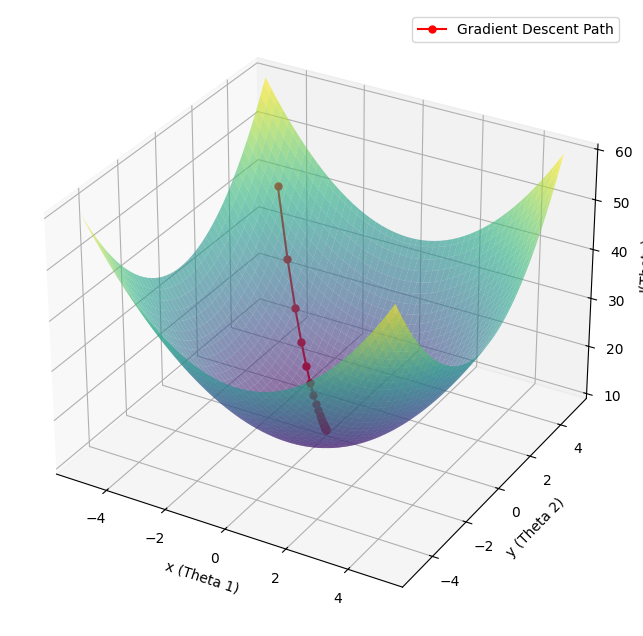

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 定义目标函数 (Loss Function)
def f(x, y):
    return x**2 + y**2

# 2. 定义梯度 (Gradient)
def gradient(x, y):
    # f对x的偏导是 2x, 对y的偏导是 2y
    return np.array([2*x, 2*y])

# 3. 梯度下降参数设置
alpha = 0.1  # 学习率 (缩放系数)
epochs = 20  # 迭代次数
current_pos = np.array([-4.0, 4.0])  # 初始点 (从山坡上开始)

# 记录路径以便绘图
history = [current_pos.copy()]

# 4. 执行梯度下降
for i in range(epochs):
    grad = gradient(current_pos[0], current_pos[1])
    # 核心公式：theta = theta - alpha * gradient
    current_pos = current_pos - alpha * grad
    history.append(current_pos.copy())

history = np.array(history)

# 5. 可视化
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制曲面
X = np.linspace(-5, 5, 100)
Y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(X, Y)
Z = f(X, Y)
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)

# 绘制下降轨迹
path_x = history[:, 0]
path_y = history[:, 1]
path_z = f(path_x, path_y)
ax.plot(path_x, path_y, path_z, color='red', marker='o', markersize=5, label='Gradient Descent Path')

ax.set_xlabel('x (Theta 1)')
ax.set_ylabel('y (Theta 2)')
ax.set_zlabel('J(Theta)')
plt.legend()
plt.show()


## 梯度下降 $—$ 案例计算

**数据集**

假设有以下贷款额度表
Salaries | Deposits | House Property （$m^2$） | Loan Amount | Name

6000 | 12000 | 55 | 30000 | Alice

8000 | 10000 | 70 | 45300 | Sylas

7500 | 16000 | 60 | 46000 | Tom

15000 | 100000| 120 | 200000 | Lee

前面1-3列为特征列，第四列（Loan Amount）为标签，第五列为无用的特征

那么可以将其写为矩阵形式:

$$ X =
\begin{bmatrix}
6000 & 12000 & 55 & 30000 \\
8000 & 10000 & 70 & 45300 \\
15000 & 100000 & 120 & 200000
\end{bmatrix}_{3 × 4} $$

其中最后一列为 **标签（Label）**

**为数据集添加偏置项**
样本数据矩阵（相当于线性代数里面的系数矩阵A）
$$ X =
\begin{bmatrix}
1 & 6000 & 12000 & 55 \\
1 & 8000 & 10000 & 70  \\
1 & 15000 & 100000 & 120
\end{bmatrix}_{3 × 4} $$

标签向量$y$ （相当于线性代数里的解向量）
$$y = [30000, 45300, 200000]^T$$

线性回归模型本质上是在求解一个非齐次（Non-homogeneous）线性方程组，即（$Ax = y$），且通常是无解的：
$$Xw = y$$
其中：
* $X$：特征值矩阵
* $w$：需要求解的参数 （权重 + 偏置）
* $y$：标签，即样本对应的真实值


**1. 确定损失函数类型**

假设采用 **MSE**

那么，损失函数为：
$$ J(w,b) = \frac{1}{2n} \sum_{i=1}^{n} (\hat{y}^{(i)}−y^{(i)})^2 $$

其中：
* $\hat{y}^{(i)}$: 某个样本的预测值，即
$$ \hat{y}^{(i)} =  \sum_{j=1}^{(m -1)} X_{ij} w_j = \theta_1X_{i1} + \theta_2X_{i2} + \theta_3X_{i3} + b$$

$X_{i}$ 为第i行样本的特征，再分别取出第i行的每一个特征值 $X_{ij}$

**2. 对具体的损失函数求导（求梯度）**

$$\begin{aligned}
\frac{∂J(θ)}{∂θ} &= \frac{1}{n} \sum_{i=1}^{n} (h_\theta(x^{(i)}) - y^{(i)}) \cdot ( h_\theta(x^{(i)}) - y^{(i)} )_{\theta}^{'} \\
&= \frac{1}{n} \sum_{i=1}^{n} (h_\theta(x^{(i)}) - y^{(i)}) \cdot \frac{∂(h_\theta(x^{(i)}))}{∂\theta} \\
&= \frac{1}{n} \sum_{i=1}^{n} (h_\theta(x^{(i)}) - y^{(i)}) \cdot \frac{∂(θ_0x_0 + θ_1x_1 + ⋯ + θ_mx_m)}{∂(θ_0, θ_1, ..., θ_m)}  ({这里的b = θ_0x_0}) \\
&= \frac{1}{n} \sum_{i=1}^{n} (h_\theta(x^{(i)}) - y^{(i)}) \cdot \begin{pmatrix}
x_0 \\
x_1 \\
\vdots \\
x_m
\end{pmatrix} \\
&= \frac{1}{n} \sum_{i=1}^{n} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x^{(i)}
\end{aligned}$$


其中：
* $x^{(i)}$: 第 $i$ 个样本的完整特征向量，即数据矩阵中的第i行样本 $X^{(i)} = \begin{bmatrix} x_1 & x_2 & ⋯ & x_n  \end{bmatrix}^T$ (例如： [工资 存款 房产面积])

如果损失函数为：$J(\theta) = \frac{1}{2n} (X\theta - y)^T (X\theta - y)$，那么梯度为：
$$\frac{\partial J(\theta)}{\partial \theta} = \frac{1}{n} X^T (X\theta - y)$$

理解：
* $(Xθ)$: 一个列向量 （$θ$ 为未知数向量， 矩阵 $X$ 为线性方程组的系数矩阵）；相当于是所有样本的预测值，称作 **“预测向量” (Prediction Vector)**
* $(Xθ - y)$: 误差，即预测结果与真实值究竟差了多少（预测值 - 真实值）
* $X^T$： 维度变成了 $m \times n$，（每一个列是一个样本，每一行是某一个特征集，例如：所有样本的薪资集合）

**3. 更新梯度下降公式**

将步骤2中的梯度带入到梯度下降公式中:

$$\theta_{\text{新}} = \theta_{\text{旧}} - \alpha \times \underbrace{\left( \frac{1}{n} \sum_{i=1}^{n} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x^{(i)} \right)}_{\text{损失函数 $J(\theta)$ 关于参数 $\theta$ 的梯度}}$$

其中： $x^{(i)}$ 为第i个样本的完整特征值向量，即矩阵中的一行数据


**4. 计算每个特征所对应的平均梯度**

假设 $ θ_0 = 0, θ_1 = 1,  θ_2 = 2,  θ_3 = 3 $ ，学习率 $ α = 0.001 $ ，偏置项 $x_0 = 1$

利用公式（$\theta_j := \theta_j - \alpha \frac{\partial J}{\partial \theta_j}$）计算每个特征的梯度，其中：

$$\frac{\partial J}{\partial \theta_j} = \frac{1}{n} \sum_{i=0}^{n} [ \underbrace{(h_\theta(x^{(i)}) - y^{(i)})}_{\text{包含了所有 } \theta} \times \underbrace{x_j^{(i)}}_{\text{只有第 } j \text{ 个特征}} ]$$

其中：
* $x_j^{(i)}$: 指的是 **第 $i$ 个样本** 在 **第 $j$ 个特征** 上的具体数值

上标 $(i)$：代表 “哪个人”（第几个样本）。比如：这是第 3 个房子的数据。

下标 $j$：代表 “哪项属性”（第几个特征）。这就必须对应你现在正在求导的那个参数 $\theta_j$。如果你在求 “面积权重 $\theta_{\text{面积}}$” 的导数，这里的 $x$ 就必须是 “面积”。

例如：计算薪资（Salary）这个特征的梯度 **$θ_1 (j=1)$**：

$$\begin{aligned}
θ_1 &= θ_1 - α ⋅ \frac{∂J}{∂θ_j} \\
&= θ_1 - α ⋅ \{ \frac{1}{n} ⋅ \sum_{i=0}^{3} (h_θ(x^i) - y^i) ⋅ x_j^{(i)} \} \\
&= 1 - (0.001) * \{ \frac{1}{3} \sum_{i=1}^{3} (h_\theta(x^i) - y^i) ⋅ x_j^i \}
\end{aligned}$$
令$t = \sum_{i=1}^{3} (h_\theta(x^i) - y^i) ⋅ x_j^i$

则有：
$$t = (0 * 1 + 1 * 6000 + 2 * 12000 + 3 * 55 - 30000) * 6000
    + (0 * 1 + 1 * 8000 + 2 * 10000 + 3 * 70 - 45300) * 8000
    + (0 * 1 + 1 * 15000 + 2 * 100000 + 3 * 120 - 200000) * 15000
$$
那么:
$$
θ_1 = 1 - (0.001) * \frac{t}{3}
$$

**5. 计算所有特征列的梯度（偏导），并更新对应的梯度 $θ$**

$$θ = \begin{bmatrix} θ_0 & θ_1 & θ_2 & ⋯ & θ_m \end{bmatrix}^{T}$$

公式：

$$θ_j = θ_j - α ⋅ Δθ_j$$

必须把 $m+1$ 个特征（含截距）的梯度全部算好，然后一起更新**整个参数向量 $\theta$**

**6. 迭代**

* 重复前面第4和第5步，不断更新参数向量 $θ = \begin{bmatrix} θ_0 & θ_1 & θ_2 & ⋯ & θ_m \end{bmatrix}^{T}$

* 直到收敛为止

## **线性模型评估**

一般使用：

*   MAE（Mean Average Error）: 反应“真实的”平均误差
*   RMSE（Root Mean Square Error）: 均方根误差



## **线性回归 API**



1.   sklearn.linear_model.LinearRegression(fit_intercept=True)
2.   sklearn.linear_model.SGDRegressor(loss="squared_loss", fit_intercept=True, learning_rate="constant")



## **总结**

**梯度下降公式**

算 $n$ 个样本分别想让参数怎么走，然后取一个“平均意见
$$\frac{\partial J}{\partial \theta} = \frac{1}{n} \sum_{i=1}^{n} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x^{(i)}$$
“算出所有样本单独的梯度 -> 加起来 -> 除以样本数 -> 得到最终的平均梯度方向”。

求平均：
1. 稳定性（不论数据多少）：
    * 如果你有 10 个样本，梯度和是 100。如果你有 10000 个样本，梯度和可能变成 100000
    * 如果只求和，样本越多，梯度就会越大，你的 **步长（Learning Rate）** 就必须设得非常非常小才能防止跑飞。除以 $n$ 之后，梯度的数值大小就和样本数量无关了，只和“平均误差”有关
2. 数学定义的一致性：
    * 损失函数 $J(\theta)$ 定义就是“均方误差”（MSE），里面有一个 $\frac{1}{n}$（或 $\frac{1}{2n}$）。对均值函数求导，自然会保留这个 $\frac{1}{n}$

**$θ$ 的解释**

$\theta$ 就是 $w$ （权重集合）和 $b$ 的合体； 在向量化计算中，为了方便，把它们打包叫 $\theta$

**线性回归模型的求解步骤**

1. 定义结构：先写出方程 $h_\theta(x) = \theta^T x$（这时候 $\theta$ 是未知的，通常设为乱猜的值作为初始值）
2. 定义目标：设立损失函数 $J(\theta)$，目标是让它越小越好。损失函数的值越小，代表拟合曲线穿过了数据集中的大多数数据点
3. 循环求解（梯度下降）：
    * 算出当前的梯度（方向）
    * 更新 $\theta$（迈一步）
    * 重复... 两种判断参数 $θ$ 是否收敛的思想：
      * 梯度趋近于 0：也就是 $\frac{\partial J}{\partial \theta} \approx 0$。这意味着我们在碗底，再怎么走也走不动了。
      * 损失函数变化极小：比如连续 10 次更新，误差 $J(\theta)$ 的减少量都小于 $0.0001$（这叫收敛/Convergence）。
4. 收敛（得到解）：
    * 当梯度接近 0，或者损失函数不再下降
    * 此时手中的 $\theta$ 就是 $\theta_{best}$（最优解）。
5. 投入使用：
    * 把求出来的 $\theta$ 代回第一步的方程。 这就是“模型训练完成”的状态。
    * 假设现在来一个新的 $x$（比如新房子的面积），你就能立刻算出 $y$（预测房价）。

**收敛**

1. 损失函数收敛 (Loss Convergence) —— “目的”这是我们在训练模型时最直观看到的指标（通常画成 Loss vs. Epochs 的曲线图）。
    * 定义：随着迭代次数增加，损失函数 $J(\theta)$ 的值不再下降，或者下降的幅度非常微小（小于某个阈值 $\epsilon$）。
    * 直观表现：那条下坡的曲线变平了。
    * 判定标准：
  $$ | J(\theta_{new}) - J(\theta_{old}) | < \epsilon$$
    （例如：误差只减少了 0.000001，我们可以认为它收敛了）。

2. 参数收敛 (Parameter Convergence) —— “手段”这是梯度下降算法内部的数学状态。
    * 定义：参数 $\theta$ 的数值不再发生变化，或者变化极其微小。
    * 数学原理：回忆更新公式：$\theta_{new} = \theta_{old} - \alpha \cdot \nabla J$如果 梯度 ($\nabla J$) 变成了 0，那么 $\theta_{new}$ 就等于 $\theta_{old}$。参数就不动了。
    * 判定标准：
  $$\| \theta_{new} - \theta_{old} \| < \epsilon$$
  或者直接判断梯度的大小：
  $$\| \nabla J(\theta) \| < \epsilon$$

**收敛的等价**

在凸优化问题（比如你正在学的线性回归）中，损失函数像一个完美的碗（平方函数）。
* 当你的参数 $\theta$ 走到了谷底（参数收敛），你的高度 $J(\theta)$ 自然也就到了最低点（损失收敛）。
* 因为谷底的坡度（梯度）是 0，所以参数也不会再动了。

所以在线性回归里：**参数收敛** $\iff$ **损失函数收敛**。

**深度学习里的收敛**

在 非凸优化（深度神经网络） 中，这两种收敛（参数收敛 于 损失函数收敛）可能会出现微妙的分离：

情况 A：损失收敛了，但参数没收敛 (Loss converges, Parameters drift)
* 场景：如果你的损失函数是一个平底的谷底（Flat Minima），像一个巨大的平原。
* 现象：损失值 $J$ 已经很低且不变了，但是参数 $\theta$ 还在这个平原上漫无目的地游走（Drifting）。
* 结果：对于预测任务来说，模型已经收敛了（效果不便），但物理上的参数还在动。

情况 B：参数收敛了，但损失没到最低 (Local Minima / Saddle Point)
* 场景：遇到了鞍点（Saddle Point）或局部最优。
* 现象：梯度接近 0，参数 $\theta$ 走不动了（收敛了）。但是损失 $J$ 并没有达到全局最小，卡在了半山腰。
* 结果：这是“假收敛”，通常需要用动量（Momentum）或者随机梯度下降（SGD）把它震出来。

## **housing price prediction**

1. **导包**

hstack(): 水平拼接数组

In [ ]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt

# split the trainning set and test set
from sklearn.model_selection import train_test_split

# standardization
from sklearn.preprocessing import StandardScaler
# normalization library
from sklearn.preprocessing import MinMaxScaler

#  API
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

# model evaluation
from sklearn.metrics import accuracy_score

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

2. 数据预处理

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=1)

3. 特征工程

In [ ]:
transfer = StandardScaler()

x_train = transfer.fit_transform(x_train)
x_test = transfer.transform(x_test)

4. 模型训练

In [ ]:
# 正规方程求解
estimator = LinearRegression(fit_intercept=True)

# 随机梯度下降
# estimator = SGDRegressor(fit_intercept=True, learning_rate="constant", eta0=0.01)

estimator.fit(x_train, y_train)

print(f"weight: {estimator.coef_}")
print(f"bias: {estimator.intercept_}")

weight: [-1.02670073  1.35041325  0.12557673  0.57522815 -2.28609206  2.13083882
  0.12702443 -3.17856741  2.64730569 -1.87781254 -2.14296387  0.6693739
 -3.92551025]
bias: 22.52227722772279


5. 模型预测

In [ ]:
y_pre = estimator.predict(x_test)
print(f"Results of Prediction: {y_pre}")

Results of Prediction: [32.65503184 28.0934953  18.02901829 21.47671576 18.8254387  19.87997758
 32.42014863 18.06597765 24.42277848 27.00977832 27.04081017 28.75196794
 21.15677699 26.85200196 23.38835945 20.66241266 17.33082198 38.24813601
 30.50550873  8.74436733 20.80203902 16.26328126 25.21805656 24.85175752
 31.384365   10.71311063 13.80434635 16.65930389 36.52625779 14.66750528
 21.12114902 13.95558618 43.16210242 17.97539649 21.80116017 20.58294808
 17.59938821 27.2212319   9.46139365 19.82963781 24.30751863 21.18528812
 29.57235682 16.3431752  19.31483171 14.56343172 39.20885479 18.10887551
 25.91223267 20.33018802 25.16282007 24.42921237 25.07123258 26.6603279
  4.56151258 24.0818735  10.88682673 26.88926656 16.85598381 35.88704363
 19.55733853 27.51928921 16.58436103 18.77551029 11.13872875 32.36392607
 36.72833773 21.95924582 24.57949647 25.14868695 23.42841301  6.90732017
 16.56298149 20.41940517 20.80403418 21.54219598 33.85383463 27.94645899
 25.17281456 34.65883942 18.6

6. 模型评估

In [ ]:
print(f"MSE: {mean_squared_error(y_test, y_pre)}")

print(f"RMSE: {root_mean_squared_error(y_test, y_pre)}")

print(f"MAE: {mean_absolute_error(y_test, y_pre)}")

MSE: 23.3808364802702
RMSE: 4.835373458200535
MAE: 3.7507121808389154


## **欠拟合 & 过拟合**

**欠拟合**

模型在训练集上表现不好，在测试集也同样表现不好 （模型过于简单）

因此欠拟合在训练集和测试集上的误差都较大



MSE: 7.837486110760636


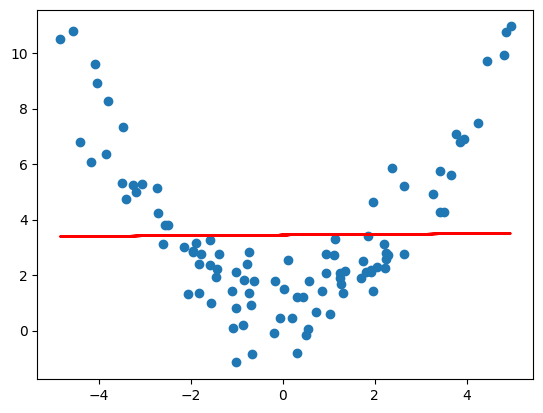

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def under_fitting():
  # 指定随机种子，每次的随机数一致
  np.random.seed(123)
  x = np.random.uniform(-5, 5, size=100)
  # normal(): 正态分布
  y = 0.4 * x ** 2 + 1 + np.random.normal(0, 1, size=100)

  estimator = LinearRegression()

  # x是一维数组，需要把它转为二维  [[]]
  x_reshaped = x.reshape(-1, 1)
  estimator.fit(x_reshaped, y)

  y_predicted = estimator.predict(x_reshaped)

  MSE = mean_squared_error(y, y_predicted)
  print(f"MSE: {MSE}")

  # 显示原始数据的分布
  plt.scatter(x, y)
  plt.plot(x, y_predicted, color='r')
  plt.show()

under_fitting()

**正好拟合**

MSE: 0.9571436362522955


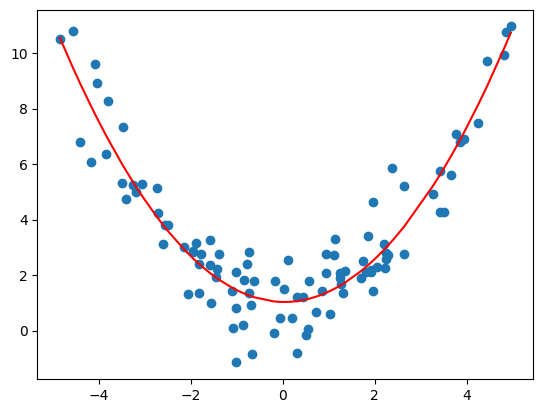

In [ ]:
def just_fitting():
  # 指定随机种子，每次的随机数一致
  np.random.seed(123)
  x = np.random.uniform(-5, 5, size=100)
  # normal(): 正态分布
  y = 0.4 * x ** 2 + 1 + np.random.normal(0, 1, size=100)

  # x是一维数组，需要把它转为二维  [[]]
  x_reshaped = x.reshape(-1, 1)
  # 特征只有一个（一列），所以模型过于简单。为模型增加一列特征，从而增加模型的复杂度
  x_expanded = np.hstack([x_reshaped, x_reshaped ** 2])

  #print(x_expanded)

  estimator = LinearRegression()
  estimator.fit(x_expanded, y)

  y_predicted = estimator.predict(x_expanded)

  MSE = mean_squared_error(y, y_predicted)
  print(f"MSE: {MSE}")

  # 显示原始数据的分布
  plt.scatter(x, y)
  plt.plot(np.sort(x), y_predicted[np.argsort(x)], color='r')
  plt.show()

just_fitting()

**过拟合**

模型在训练集表现优异，在测试集表现不好 （模型过于复杂）

过拟合在训练集的误差较小，但是在测试集误差较大

**原因：** 原始特征过多，存在一些嘈杂的特征，模型过于复杂是因为模型尝试去兼顾各个测试数据点

MSE: 0.9151273635800139


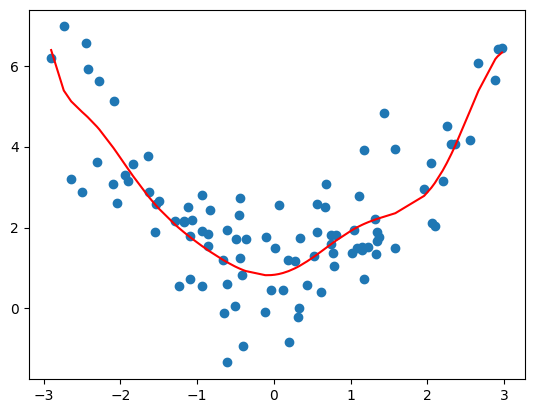

In [ ]:
def just_fitting():
  # 指定随机种子，每次的随机数一致
  np.random.seed(123)
  x = np.random.uniform(-3, 3, size=100)
  # normal(): 正态分布
  y = 0.6 * x ** 2 + 1 + np.random.normal(0, 1, size=100)

  # x是一维数组，需要把它转为二维  [[]]
  x_reshaped = x.reshape(-1, 1)
  # 特征只有一个（一列），所以模型过于简单。为了模拟过拟合，为模型增加多个列特征，从而增加模型的复杂度
  x_expanded = np.hstack([x_reshaped, x_reshaped ** 2, x_reshaped ** 3, x_reshaped ** 4, x_reshaped ** 5, x_reshaped ** 6, x_reshaped ** 7, x_reshaped ** 8, x_reshaped ** 9, x_reshaped ** 10])

  #print(x_expanded)

  estimator = LinearRegression()
  estimator.fit(x_expanded, y)

  y_predicted = estimator.predict(x_expanded)

  MSE = mean_squared_error(y, y_predicted)
  print(f"MSE: {MSE}")

  # 显示原始数据的分布
  plt.scatter(x, y)
  plt.plot(np.sort(x), y_predicted[np.argsort(x)], color='r')
  plt.show()

just_fitting()

## **欠拟合解决方法**

**出现欠拟合的原因**

学习到数据的特征过少

**解决办法**

添加其他特征

*   有时出现欠拟合是因为特征项不够导致的，可以添加其他的特征来解决
*   组合、泛化 与 相关性 三类特征是添加特征的重要手段

添加多项式特征


*   模型过于简单的常用套路，例如：将线性模型通过添加二次项 或 三次项 使得模型泛化能力更强




## **解决过拟合**



*   **重新清洗数据**

    对于过多的异常点数据、数据不纯的地方再进行处理

*   **增大数据的训练量**

    对原来的数据训练的太过了，增加数据量的情况下，会缓解

*   **正则化**

    解决模型过拟合的方法，在机器学习、深度学习中大量使用

*   **减少特征维度**

    由于特征多，样本数量少，导致学习不充分，模型的泛化能力差




**正则化 （Normalization）**

在模型训练中，数据中有些特征影响模型复杂度、或者某个特征的异常值较多，所以要尽量去减少这个特征的影响（甚至删除某个特征的影响），这就是正则化。

**思想：**

通过在损失函数中添加正则化项，来抵消异常值对权重 $W$ 的影响

**$L1$ 正则化**

在损失函数中添加 $L1$ 正则化项：
$$ J(w) = MSE(w) + \alpha \cdot \sum_{i=1}^{n} |w_i| $$


*   **$α$** ： 叫做惩罚系数，该值越大，则权重调整的幅度就越大，即：表示对特征权重处罚力度越大
*   $L1$  正则化会使得权重趋向于0，甚至等于0，使得某些特征失效，达到特征筛选的目的
*   正则项是绝对值函数 ($ f(x) = |x| $)
*   $ \sum|w_i| $: 权重的总和

**API**




In [ ]:
from sklearn.linear_model import Lasso

estimator = Lasso(alpha=1)

alpha：惩罚系数

**$L2$ 正则化**

在损失函数中添加 $L2$ 正则化项：
$$ J(w) = MSE(w) + \alpha \cdot \sum_{i=1}^{n} w_i^2 $$


*   **$α$** ： 叫做 **惩罚系数**，该值越大，则权重调整的幅度就越大，即：表示对特征权重处罚力度越大
*   $L2$  正则化会使得权重趋向于0，一般不等于0；从而达到特征筛选的目的
*   正则项是一元二次函数 ($ f(x) = x^2 $)
*   使用 $L2$  正则化的线性回归模型是岭回归
*   $ \sum w_i^2 $: 权重平方 的 总和

**API**




In [ ]:
from sklearn.linear_model import Ridge

estimator = Ridge(alpha=1)

alpha：惩罚系数

# 3. Logistic Regression (逻辑回归)

## **应用场景：**

适用于 二分类的场景（例如，结果要么是A要么是B）

实际应用场景：预测疾病（阳性 或 阴性）、情感分析（正面 或 负面）

但是通过嵌套可以实现三分类，或多分类


## **原理**



**Logistic Regression**

*  **一种分类模型**
*  把线性回归的输出，作为逻辑回归的输入
*  逻辑回归的输出是 $(0, 1)$ 之间的值 （概率）

**基本思想**

1. 利用线性模型 $f(x) = W^TX + b$ 根据特征的重要性 计算出一个值

2. 使用 sigmoid 函数将 $f(x)$ 的输出值映射为概率值
    *  设置阀值（例如：0.5），输出的概率值大于0.5，则将未知样本输出为 1 类
    *  否则输出为 0 类

**总结**

1. 数据 经过线性回归 得到预测值

2. 将预测值传给 Sigmoid 激活函数 通过映射 得到概率 (0, 1)

3. 根据阀值 决定是 A 还是 B

## **损失函数**

**二元交叉熵损失函数（Binary Cross Entropy Loss）**

$$Loss = - \sum_{i=1}^{n} (y_i log(p_i) + (1 - y_i)log(1 - p_i)) $$
其中：
*  $p_i = sigmoid(W^T X + b)$ 是逻辑回归的输出结果（概率）
*  $y_i$ ： 第i个样本的标签值；正样本： $y_i = 1$，负样本：$y_i = 0$
*  '$-$': 取负数是因为 $p_i$ 的值在 $(0, 1)$ 区间，而在这段区间中，函数 $f(x) = log(x)$ 的值是负数。所以累计求和后肯定得到的是一个负数，求和后取负数，正好变成**正数（损失值）**。
    * 这样一来，就把最大化问题（极大似然估计求最大概率）转化为最小化问题（这样就可以利用梯度下降算法）

**交叉熵损失函数（Cross Entropy Loss）的推导过程**

每个样本的预测值有A、B两个类别，真实类别对应的位置的概率值越大越好

假设分类为 1 类的概率为 **$p$**，且 **$p = P(y|x)$**
1. 1个样本的概率表示
$$ f(x) =
\begin{cases}
p, & y = 1 \\
1 - p, & y = 0
\end{cases}
$$

    将样本类别 $y = 1$ 的概率 $p$，和样本类别 $y = 0$ 的概率 $(1 - p)$，合成为一个函数
$$ L = p^y (1 - p)^{1 - y}$$
  *  当样本是1类别，模型预测的 $p$ 越大越好
  *  当样本是0类别，模型预测的 $(1 - p)$ 越大越好

2. n 个样本的概率表示
    
    假设：有 n 个独立的样本 $[ (x_1, y_1), (x_2, y_2), ⋯, (x_n, y_n) ]$, 所有样本都预测正确的概率：
$$\begin{aligned}
P(Y|X, \theta) &= P(y_1|x_1) P(y_2|x_2) ⋯ P(y_n|x_n) \\
&= \prod_{i=1}^n \underbrace{P(y_i | x_i; \theta)}_{\text{抽象符号}} \\
&= \prod_{i=1}^n \underbrace{p_i^{y_i} (1 - p_i)^{1 - y_i}}_{\text{二分类展开}}
\end{aligned}$$

*  $p_i$： 表示每个样本被分类正确时的概率
*  **$p_i = P(y_i|x_i)$**
*  $y_i$： 表示每个样本的真实类别 (0 或 1)

    问题转化为：让联合概率事件最大时，估计参数 $ θ \quad ( W , b) $，这就是**极大似然估计**

3. 极大似然函数转为**对数似然函数**，取 $log$ 优化函数：将连乘转换为对数加法
$$L(\theta) = P(\mathbf{Y} | \mathbf{X}, \theta) = \prod_{i=1}^{n} P(y_i | x_i, \theta) \text{(1. 极大似然函数)} $$

$$\begin{aligned}
\ell(\theta) &= \log \left( \prod_{i=1}^{n} P(y_i | x_i, \theta) \right) = \log \left( \prod_{i=1}^{n} p_i^{y_i} (1 - p_i)^{1 - y_i} \right) & \text{(2. 两边取对数)} \\
&= \prod_{i=1}^{n} \log \left(  p_i^{y_i} (1 - p_i)^{1 - y_i} \right) \\
&= \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right] & \text{(3. 转换为对数加法)}
\end{aligned}$$

其中：
$$p_i = P(y_i|x_i) = \frac{1}{1 + e^{-(w^T x + b)}} $$

*  这里是利用 Sigmoid 函数 将线性回归的结果 $w^T x + b$ 映射到 $[0, 1]$ 之间，从而符合概率的定义

4. 为了将其转化为最小化问题，定义交叉熵损失函数

    取负号并求平均（为了最小化误差且不受样本量影响）：
$$Loss(θ) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]$$
*  θ: 指的是 $W, b$
*  $y_i$：样本的真实标签（$1$ 或 $0$）
*  $p_i$: 在**当前模型参数**下，观测到**所有真实标签的概率总和（对数空间）**
*  '$-$': 由于$p_i$ 的值在 $(0, 1)$ 区间，而在这段区间中，函数 $f(x) = log(x)$ 的值是负数。所以累计求和后肯定得到的是一个负数，求和后取负数，正好变成正数（损失值）。方便后面使用梯度下降算法
*  $p_i = sigmoid(W^T X + b)$

5. 利用梯度下降算法

    前面得到的 $L(θ)$ 是极大似然函数，它的值是一个概率，这个概率值越大，说明模型给出的预测与真实情况越吻合

    将极大似然函数转为 $Loss(θ)$ 损失函数后，就可以利用梯度下降算法来迭代求解 参数 $θ$ 的值。

    通过微积分对参数求偏导，得到梯度。**将概率（Probability）转化成损失（Loss）**，寻找一组最小的损失函数值（负值）。

**logistic regression Loss 总结**

逻辑回归 损失函数 $Loss(θ)$ = 极大似然估计值取负数
$$L(θ) = - ( \text{极大似然估计值} )$$

## **逻辑回归中的 数学基础**

### Sigmoid 函数

sigmoid 函数 也叫 **激活函数** 或 **S型函数**

数学公式为：
$$ f(x) = \frac{ 1 }{ 1 + e^{ -x } } $$

*   作用：将 $ (-∞, +∞) $ ,(即线性回归的预测值), 映射到 $ (0, 1) $ 之间，结合阀值，划分正负样本
*   数学性质：单调递增函数，拐点在 $ x = 0, y = 0.5 $
*   导数：
$$ f'(x) = \frac{e^{-x}}{ (1 + e^{-x} )^2} = \frac{ 1+e^{-x} }{ (1+e^{-x})^2 } \cdot \frac{1 + e^{-x} -1 } { 1 + e^{-x} } = f(x) ⋅ [ 1 - f(x)]$$

### 术语解释

1. **独立 (Independent)**
*  定义：一个随机变量的观测结果，不会影响另一个随机变量的结果。
*  直观理解：就像你多次抛同一枚硬币。你第一次抛出“正面”，完全不会影响你第二次抛出“正面”还是“反面”。

2. **同分布 (Identically Distributed)**
*  定义：所有的随机变量都来自于同一个概率分布。
*  直观理解：你每次抛的都是同一枚硬币，或者虽然不是同一枚，但这些硬币的物理性质（正面朝上的概率）是一模一样的。
*  反例：如果你第一次抛的是正常的硬币，第二次抛的是一枚两面都是正面的“老千硬币”，那这就不是“同分布”。

3. **独立同分布（Independent and Identically Distributed）**
*  简称 i.i.d.
*  满足i.i.d.例子：

    Coles 门口随机采访顾客的年龄：
    *  独立：你采访第一个人的年龄，不会改变第二个人的年龄。
    *  同分布：所有被采访的人都属于“来这家 Coles 购物的群体”，他们的年龄分布遵循同一个规律。
    如果不满足i.i.d.:
    *  不独立：比如你采访的是一家人。如果爸爸 40 岁，那么小孩很可能只有几岁。这就不再是独立采样，数据之间有了关联。
    *  不同分布：比如你上午在大学校园采了 10 个人，下午去养老院采了 10 个人。这两组数据的“分布规律”完全不同，不能混在一起看。

### 概率

**符号解读**

* **逗号 ,**：代表“**且**”（同时发生）。

* **竖杠 |**：代表“**在……的前提下**”（已经发生）。

**联合概率（Joint Probability）**

在不同的教材或论文里，它有几种不同的写法 **{$P(A, B)$ 或 $P(A \cap B)$}** ，但意思完全一样
* **通用公式（乘法原理）：**
$$P(A, B) = P(A) \cdot P(B|A) = P(A ∩ B)$$
或者：
$$P(A, B) = P(B) \cdot P(A|B)$$

* **特殊情况（当 A, B 相互独立时）：**
$$P(A, B) = P(A) \cdot P(B)$$

如果不独立：你必须老老实实地用这个公式。比如：$P(\text{下雨}, \text{地湿}) = P(\text{下雨}) \cdot P(\text{地湿} | \text{下雨})$。

如果独立：你会发现 $P(B|A)$ 其实就等于 $P(B)$（因为 $A$ 对 $B$ 没影响），于是公式自然演变成了简化版。

**条件概率（Conditional Probability）**

定义：A发生的情况下，B发生的概率，记作:

$$P(B | A) = \frac{P(A, B)} {P(A)} = \frac{P(A \cap B)}{P(A)} =  \frac{A \text{ 和 } B \text{ 同时发生的概率}} {A \text{ 发生的概率}} $$
$$ = \frac{\text{A 和 B 重叠的部分}} {\text{A 的面积}} $$
* **要求**：$P(A) > 0$（前提条件必须是有可能发生的）
* **它本质上是联合概率在 A 范围内的占比**
* **特例：**如果事件A，B相互**独立**，那么事件B在A发生的情况下的发生概率就是自己本身发生的概率
$$P(B|A) = \frac{P(A, B)} {P(A)} = \frac{P(A) ⋅ P(B)} {P(A)} = P(B)$$

为了让你在后续学习（特别是处理复杂的机器学习模型）时直觉更准，我们可以从以下三个维度来拆解 $P(B|A)$：

1. 样本空间的“缩减”这是最直观的理解方式：
    *   **原始状态**：我们在考虑所有可能发生的情况（整个大圆圈）。
    *   **已知 $A$ 发生**：所有不属于 $A$ 的可能性都被“扔掉”了。现在的世界只剩下 $A$ 这么大。
    *   **$P(B|A)$**：就在这剩下的 $A$ 范围里，看一看有多少面积是被 $B$ 覆盖的。
2. 信息论视角：信息的价值
*   如果 $A$ 和 $B$ 独立，那么 $A$ 的发生没有提供任何关于 $B$ 的有用信息，所以 $P(B|A) = P(B)$。
*   如果 $A$ 和 $B$ 相关，$A$ 的发生就给你提供了“内幕消息”。
    *   正相关：已知 $A$ 发生， $B$ 发生的概率上升了。
    *   负相关：已知 $A$ 发生， $B$ 发生的概率下降了。
3. 一个容易混淆的点：先后顺序虽然我们常说“在 $A$ 发生的前提下”，但这并不意味着 $A$ 在时间上一定要先于 $B$ 发生。
*   例子：你看到地是湿的（事件 $A$），推测刚才是否下过雨（事件 $B$）。
*   即使下雨是先发生的，你依然可以计算 $P(\text{刚才下雨} | \text{现在地湿})$。这在概率论里叫**逆概率**，也是贝叶斯定理的核心。

**条件概率（Conditional Probability）实际习题**

假设你在 Coles 统计发现：
*  顾客买牛奶的概率 $P(\text{牛奶}) = 0.4$
*  顾客既买牛奶又买面包的概率 $P(\text{牛奶}, \text{面包}) = 0.2$
那么，“已知一个顾客买了牛奶，他再买面包”的条件概率就是：
$$P(\text{面包} | \text{牛奶}) = \frac{P(\text{牛奶}, \text{面包})}{P(\text{牛奶})} = \frac{0.2}{0.4} = 0.5$$

**多变量联合概率**

1. 链式法则的推导逻辑
* 2个变量：$P(A, B) = P(A) \cdot P(B|A)$
* 3个变量：我们可以把 $(A, B)$ 看作一个整体
$$P(A, B, C) = P(A, B) \cdot P(C|A, B)$$
代入上面的结果：
$$P(A, B, C) = P(A) \cdot P(B|A) \cdot P(C|A, B)$$
* 4个变量：$$P(A, B, C, D) = P(A) \cdot P(B|A) \cdot P(C|A, B) \cdot P(D|A, B, C)$$

2. 通用公式

    对于 $n$ 个随机变量 $X_1, X_2, \dots, X_n$，联合概率可以拆解为：
    $$\Large P(X_1, \dots, X_n) = \prod_{i=1}^{n} P(X_i | X_1, \dots, X_{i-1})$$
    解读：第 $i$ 个变量发生的概率，取决于它前面所有的变量（历史信息）。

    推到展开：已知 $P(x_1, x_2) = P(x_1) ⋅ P(x_2|x_1)$，每次剥掉一个（或一组）变量，剩下的部分变成条件概率
$$\begin{aligned}
P(x_3, \dots, x_n | x_1, x_2) &= P(x_3 | x_1, x_2) \cdot P(x_4, \dots, x_n | x_1, x_2, x_3)
\end{aligned}$$
    那么：
  $$\begin{aligned}
  P(x_1, \dots, x_n) &= P(x_1, x_2) \cdot P(x_3, \dots, x_n | x_1, x_2) \\
  &= P(x_1) P(x_2 | x_1) \cdot P(x_3 | x_1, x_2) \cdot P(x_4, \dots, x_n | x_1, x_2, x_3) \\
  &= P(x_1) P(x_2 | x_1) P(x_3 | x_1, x_2) \dots P(x_n | x_1, \dots, x_{n-1})
  \end{aligned}$$

3. 在深度学习里的实际应用
    
    最典型的例子就是 NLP（自然语言处理） 中的文本生成：

    假设我们要生成一句话：“我 爱 学习”。
    * $X_1 = \text{“我”}$
    * $X_2 = \text{“爱”}$
    * $X_3 = \text{“学习”}$

    模型计算这句话出现的总概率（联合概率）时，实际上是在做连乘：
    1. $P(\text{“我”})$：这句话开头是“我”的概率。
    2. $P(\text{“爱”} | \text{“我”})$：已知第一个字是“我”，第二个字是“爱”的概率。
    3. $P(\text{“学习”} | \text{“我”, “爱”})$：已知前两个字是“我爱”，接下来的词是“学习”的概率。
    
    这就是为什么像 GPT 这样的自回归模型是一次只预测一个词的原因。

    GPT 在生成回复时确实没法在大序列上并行（只能一个一个吐词）；但在训练阶段，它利用了一个叫“教师强制（Teacher Forcing）”的技巧，实现了完美的并行化

**多变量条件概率**

1. 事件 $x_1, x_2, ⋯, x_n$ **不独立**： 链式法则 (The Chain Rule)
$$P(x_1, x_2, x_3, \dots, x_n | \theta) = P(x_1 | \theta) \cdot P(x_2 | x_1, \theta) \cdot P(x_3 | x_1, x_2, \theta) \dots$$

2. 假设事件 $x_1, x_2, ⋯, x_n$ **独立**：
$$P(x_1, x_2, \dots, x_n | \theta) = P(x_1 | \theta) \cdot P(x_2 | \theta) \cdot \dots \cdot P(x_n | \theta) = \prod_{i=1}^{n} P(x_i | \theta)$$

**贝叶斯定理 (Bayes' Theorem)**

1. 无论 $A$ 和 $B$ 是什么关系，它们的联合概率 $P(A, B)$ 都有两种拆解方式：
*   以 $B$ 为前提：$P(A, B) = P(B) \cdot P(A | B)$
*   以 $A$ 为前提：$P(A, B) = P(A) \cdot P(B | A)$

2. 既然左右两边都等于同一个 $P(A, B)$，那它们彼此也一定相等：
$$P(B) \cdot P(A | B) = P(A) \cdot P(B | A)$$

3. 为了求出 $P(B | A)$，我们把 $P(A)$ 除到右边，就得到了贝叶斯定理 (Bayes' Theorem)：$$ P(B | A) = \frac{P(A | B) \cdot P(B)}{P(A)}$$

**贝叶斯定理在深度学习中的作用**

它解决了一个核心矛盾：**我们想知道的往往很难直接观测，而容易观测的往往不是最终答案**。

在机器学习中，我们通常把 $B$ 看作模型参数（或类别），把 $A$ 看作观测到的数据：
*   $P(B)$ (**Prior, 先验概率**)：在看到数据之前，我们对规律的“主观经验”。
*   $P(A | B)$ (**Likelihood, 似然度**)：如果规律是真的，观测到这些数据的可能性有多大
*   $P(B | A)$ (**Posterior, 后验概率**)：**核心目标！** 既然我们看到了这些数据，这个规律是真的可能性有多大？

**例子：**

一个垃圾邮件分类器：
*  $B$：这封邮件是“垃圾邮件”。
*  $A$：邮件里出现了“中奖”这个词。
1. 先验 $P(B)$：平时垃圾邮件大概占收件箱的 20%。
2. 似然 $P(A|B)$：如果是垃圾邮件，出现“中奖”的概率很高（比如 80%）。
3. 计算后验 $P(B|A)$：当你看到“中奖”这个词时，这封邮件是垃圾邮件的概率就从初始的 20% 猛增到了一个更高的数值。

**计算贝叶斯公式中的 $P(A)$**

很难直接算出 $P(A)$ 是多少，需要借助**全概率公式 (Law of Total Probability)**
1. 直观理解：分而治之想象你要计算“一个人走在街上带伞”的总概率 $P(\text{带伞})$。

    这取决于天气，而天气可能有“晴天”、“阴天”、“雨天”三种情况。
    
    全概率公式的思想就是：把复杂的大概率，拆解成若干个简单场景下的条件概率之和。

2. 数学表达
假设事件 $B_1, B_2, \dots, B_n$ 是对整个样本空间的一个完备划分（也就是说，这些情况互斥，且加起来涵盖了所有可能，比如刚才说的三种天气）。

    那么，事件 $A$ 发生的总概率为：
    $$P(A) = \sum_{i=1}^{n} P(A | B_i) \cdot P(B_i)$$

    通俗解释：
    $P(A) = (A\text{在场景}B_1\text{发生的概率} \times \text{场景}B_1\text{出现的概率}) + (A\text{在场景}B_2\text{发生的概率} \times \text{场景}B_2\text{出现的概率}) + \cdots$

3. 贝叶斯公式的完全体:

    把全概率公式代入贝叶斯公式的分母
    $$\Large P(B_i | A) = \frac{P(A | B_i) P(B_i)}{\sum_{j=1}^{n} P(A | B_j) P(B_j)}$$

    解读：只要知道在各种不同假设（$B_j$）下数据（$A$）出现的概率，我们就能反过来推导哪种假设最可靠。


### 极大似然估计

**极大似然估计（Maximum Likelihood Estimation, 简称 MLE）**


它是统计学和机器学习（尤其是神经网络训练）的灵魂，**MLE 就是寻找那个能让当前观测数据出现概率最高的“模型参数”**

核心思想： 根据**观测到的结果（样本）**来**估计模型算法中的未知参数**

1. 直观理解：反推“真相”
*  传统概率：已知参数 $\theta$（比如硬币是均匀的），预测结果 $X$（连续抛 10 次，正面朝上的概率）。
*  极大似然（MLE）：已知结果 $X$（我抛了 10 次，发现 8 次正面），反推参数 $\theta$（这枚硬币到底是不是均匀的？还是它本身就是偏心的？）。

    **MLE 的逻辑**：我们要找到一个 **参数值$\theta$**， 使得在这个参数下，观察到现在这组实验结果（8 次正面）的 **概率最大**。

2. 数学上的**“似然函数” (Likelihood Function)**

    **写法：** $$P(D | \theta) \quad \text{或者} \quad \mathcal{L}(\theta | D) \quad \text{或者} \quad L(\theta; D)$$

    假设我们有一组**独立同分布**的观测数据 $x_1, x_2, \dots, x_n$，令 $D = \\{ x_1, x_2, \dots, x_n \\}$
     。它们的**联合概率**（现在我们叫它“**似然函数**”）可以写作：
    $$L(\theta) = P(x_1, x_2, \dots, x_n | \theta) = P(D|θ) \quad {（L代表似然函数，而不是损失函数）}$$
    根据**独立变量联合概率公式**，可以拆解为连乘：
    $$L(\theta) = \prod_{i=1}^{n} P(x_i | \theta) = P(x_1|θ) ⋅ P(x_2|θ) ⋯ P(x_n|θ)$$

例子：箱子里有黑白两种球，比例未知（参数 $\theta$）。
*  实验结果：你随机摸了 3 次，结果是：黑、黑、白。
*  假设 1：如果黑球占 10%，那么出现“黑黑白”的概率很低。
*  假设 2：如果黑球占 90%，那么出现“黑黑白”的概率也一般。
*  MLE 推断：你会发现，只有当假设“黑球占 $2/3$”时，出现这个实验结果的概率才是最高的。所以，MLE 的估计值就是 $\hat{\theta} = 2/3$。


**Maximum Likelihood Estimation 习题**

假设有一枚**不均匀硬币**，出现正面的概率和出现反面的概率是不同的。假设出现**正面的概率为 $θ$**，抛了6次得到**现象D** = {正， 反， 反， 正， 正， 正}。每次投掷事件都是**相互独立**的。那么，根据**现象D**，**估计参数 $θ$** 是多少？

1. 正面概率为 $θ$，那么：反面概率为 （$1 - θ$）
2. 写出似然函数 $L(\theta)$

    由于每次投掷是**相互独立**的，根据**联合概率公式**，这 6 次投掷同时发生的概率等于**每次概率**的**连乘**：
$$\begin{aligned} L(\theta) &= P(D | \theta) \\
&= P(D_1|θ) ⋅ P(D_2|θ) ⋯ P(D_6|θ) \\
&= \theta \cdot (1-\theta) \cdot (1-\theta) \cdot \theta \cdot \theta \cdot \theta \\
&= θ^4 ⋅ (1 - θ)^2
\end{aligned}$$

3. 因为概率问题是随机的，也就是没有固定解，例如：
*  如果硬币正反概率是 $0.5$（均匀），你抛 6 次可能得到“4正2反”。
*  如果硬币正反概率是 $0.6$（不均匀），你抛 6 次也可能得到“4正2反”。
*  甚至如果概率是 $0.99$，你依然有那么一点点极其微小的可能得到“4正2反”。

    既然 $\theta = 0.5, 0.6, 0.7 \dots$ 都有可能导致你看到的现象，那我们到底该选哪一个作为“答案”呢？

    对于每一个可能的 $\theta$，我们算一下：如果真相是这个 $\theta$，产生“4正2反”的可能性（似然值）有多大？既然我们要给出一个最合理的估计值，那自然是选那个**得分最高（可能性最大）**的 $\theta$。

    **所以，“寻找最大值”的过程，本质上就是我们在所有可能的参数中，寻找“最像真相”的那一个。**
    
    那么：问题转化为一个关于概率（$θ$）的函数，那么要根据现象D，求解$θ$，就变成了求解其最大值（即最大的概率），最大概率发生的就是真相

4. 求导
$$ \begin{aligned}
\frac{∂L(θ)} {∂θ} &= 4 ⋅ θ^3 ⋅ (1 - θ)^2 + θ^4 ⋅ 2 ⋅ (1 - θ) ⋅ (-1) \\
&= (1 - θ) ⋅ [4θ^3 ⋅ (1 - θ) - 2θ^4] \\
&= (1 - θ) ⋅ θ^3 ⋅ [4 ⋅ (1 - θ) - 2θ] \\
&= (1 - θ) ⋅ θ^3 ⋅ (4  - 6θ)
\end{aligned}$$

5. 令 导数为零
    $$\frac{∂L(θ)} {∂θ} = 0$$
    解得：$θ_1 = 1, θ_2 = 0, θ_3 = \frac{2}{3}$

6. 如果$θ = 1$ 或者 $θ = 0$，说明抛掷硬币出现正面为 必然事件 或 不可能事件。所以，正确的 $θ$ 取值只能为 $θ = \frac{2}{3}$

    即：根据现象D，抛出正面的概率最可能是 $\frac{2}{3}$


### 大数定律


**Weak Law of Large Numbers** 和 **Strong Law of Large Numbers** 成立的两个前提：
*  独立性：每次实验互不干扰
*  同分布：大家遵循同一个 $\mu$

**参数 $μ$ 解释**

在大数定律 (LLN) 和 中心极限定理 (CLT) 中，$\mu$ 指的是随机变量的理论期望值（Expected Value）

1. $\mu$ 的数学本质

    如果你的随机变量是 $X$，那么 $\mu$ 的计算公式为：
    *  离散情况（如硬币、骰子）：$\mu = E(X) = \sum (x_i \cdot P(x_i))$
    *  连续情况：$\mu = E(X) = \int x f(x) dx$

2. 在不同场景下的具体含义
    
    场景 A：投掷硬币（你的例子）
    *  随机变量 $X$：正面记为 1，反面记为 0。
    *  假设：正面的真实概率是 $\theta$。
    *  理论期望值 $\mu$：
    $$\mu = (1 \cdot \theta) + (0 \cdot (1-\theta)) = \theta$$
    *  结论：在大数定律里，当 $n \to \infty$ 时，你的样本平均值 $\bar{X}_n$ 趋近的那个 $\mu$，其实就是这枚硬币真实的正面概率。

    场景 B：投掷标准骰子
    *  随机变量 $X$：点数 $\\{1, 2, 3, 4, 5, 6\\}$。
    *  理论期望值 $\mu$：
    $$\mu = \frac{1+2+3+4+5+6}{6} = 3.5$$
    *  结论：如果你投 10,000 次骰子，这 10,000 个点数的平均值 $\bar{X}_n$ 一定会非常接近 3.5。

3. $\mu$ 在两个定理中的“角色”
*  在大数定律中：$\mu$ 是**“终点站”**。定理保证了无论你从哪出发，只要路够长，最后一定能走到 $\mu$ 这个地方。
*  在中心极限定理中：$\mu$ 是**“对称轴”**。定理告诉我们，样本平均值的波动是以 $\mu$ 为中心，对称地向两边扩散，形成那个钟形曲线。

4. 深度学习背景下的 $\mu$

    Batch Normalization (批归一化)，它的核心操作之一就是：减去均值 $\mu$，除以标准差 $\sigma$。

    这里的 $\mu$ 就是当前这一批数据（Batch）的平均特征值。根据大数定律，当 Batch 足够大时，这个计算出来的样本均值就能很好地代表整个数据集的真实均值 $\mu$。

**总结**
*  $\bar{X}_n$ 是你手里拿到的数据算出来的平均数（会变）
*  $\mu$ 是大自然设定的规则（不变）

    大数定律说： **$\bar{X}_n \approx \mu$**，中心极限定理说： **$\bar{X}_n - \mu$** 服从正态分布。

1. **弱大数定律 (Weak Law of Large Numbers)**

$$\lim_{n \to \infty} P(|\bar{X}_n - \mu| < \varepsilon) = 1$$

*  $\bar{X}_n$ ： $n$ 个观测样本的算术平均值， 读作 “X-bar”； 加这个下标 $n$ 是为了强调：这个平均值是随着样本数量的变化而变化的。
*  它用概率的形式描述了平均值向真值“聚集”的过程。
*  通俗解释：只要试验次数 $n$ 足够大，样本平均值 $\bar{X}_n$ 与真值 $\mu$ 之间的差距（即使是极小的距离 $\varepsilon$）大于某个数的概率就会趋近于 0。也就是说，平均值极大概率就在真值附近。

2. **强大数定律 (Strong Law of Large Numbers)**

$$P(\lim_{n \to \infty} \bar{X}_n = \mu) = 1$$

通俗解释： 随着试验次数趋于无穷大，样本平均值**几乎处处（Almost surely）**等于理论真值。这不再是概率上的“靠近”，而是一种确定性的收敛。

## **API**

sklearn.linear_model.LogisticRegression(solver='liblinear', penalty='l2', C=1.0)

*   solver：损失函数优化方法
    *  liblinear 对小数据集场景训练速度更快，sag 和 saga 对大数据集更快一些
    *  正则化：sag 和 saga 支持 L2 正则化 或者 没有正则化。liblinear 和 saga支持 L1 正则化

*   penalty：正则化的种类， l1 或者 l2
*   C：正则化力度
*   默认将类别数量少的当做正例


## **案例 —— 癌症分类预测**


### 数据描述

1.  699 条样本，共11列数据。其中，第一列是用于检索的id，后9列分别是与肿瘤相关的医学特征，最后一列表示肿瘤类型的数值
2.  包含16个缺失值，用“？”标出
3.  2表示良性，4表示恶性

## **Logistic Regression 评估**

### 混淆矩阵 (confusion matrix)

对于二分类问题，混淆矩阵是一个 $2 \times 2$ 的表格   
   
                                      预测为正 (Positive)              预测为负 (Negative)
      实际为正 (Actual Positive)       TP (True Positive - 真阳性)      FN (False Negative - 假阴性)
      实际为负 (Actual Negative)       FP (False Positive - 假阳性)     TN (True Negative - 真阴性)

*  TP: 预测是 1，实际也是 1（猜对了）。

*  TN: 预测是 0，实际也是 0（猜对了）。

*  FP: 预测是 1，实际是 0（误报，Type I Error）。

*  FN: 预测是 0，实际是 1（漏报，Type II Error）。

### Precision（精确率）

对正例样本的预测准确率，即 **真正例** 在 **预测结果为正例** 中的**占比**。

计算方法：
$$P = \frac{TP}{TP + FP}$$

### Recall rate（召回率）

**预测为真正例样本** 占 **所有真实正例样本** 的比重。

计算：
$$R = \frac{TP}{TP + FN}$$

### F1 score


*  模型的 精度 和 召回率 的综合评估
*  计算：
$$F1 = \frac{2 × Precision × Recall}{Precision + Recall}$$

### ROC曲线

**真正率（TPR）**

正样本中 被 预测为正样本 的概率 TPR（True Positive Rate）

**假正率（FPR）**

负样本中，被预测为正样本的概率 FPR （False Positive Rate）

通过 TPR 和 FPR 可以描述模型对 正/负样本的分辨能力


**ROC曲线 （Receiver Operating Characteristic curve）**

一种常用于评估分类模型性能的可视化工具。

ROC以模型的 TPR为纵轴，FPR为横轴，它将模型在不同阈值下的表现以曲线形式展现出来

坐标点（FPR, TPR）
1.  点 $(0, 0)$：所有负样本都预测正确，所有正样本都预测错误。相当于（FPR值为0， TPR值为0）

2.  点 $(1, 0)$：所有的负样本都预测错误，所有的正样本都预测错误

3.  点 $(1, 1)$：所有的负样本都预测错误，所有的正样本都预测正确

4.  点 $(0, 1)$：所有负样本都预测正确，所有正样本都预测正确


**AUC （Area Under the ROC Curve）曲线下面积**

曲线下面积（AUC）越大，表示分类器性能越好

*  当 $AUC = 0.5$ 时，分类器的性能等同于随机猜测
*  当 $AUC = 1$ 时，表示分类器的性能完美，能够完全正确地将正负例分类

## ***one-hot编码***

### **definition**



One-hot 编码（独热编码）是一种把 **离散的类别型数据** 转换成 **数值向量** 的表示方法：对于一个有 $K$ 个类别的特征，用长度为 $K$ 的 0/1 向量表示它；属于哪个类别，就把对应位置置为 1，其余为 0。

### **instance**



假设：“颜色”这个特征有 3 个类别：红、绿、蓝，那么：
*  红 $→ [1, 0, 0]$
*  绿 $→ [0, 1, 0]$
*  蓝 $→ [0, 0, 1]$

如果把类别直接编码成数字（例如 红=1，绿=2，蓝=3），模型可能会误以为：
*  绿(2) 比 红(1) “更大”
*  蓝(3) 与 绿(2) 的距离比与 红(1) 的距离更近

但类别本质上没有大小关系（nominal），one-hot 就能避免这种“虚假的顺序与距离”。

例如：特征“性别”有 Male 和 Female两个值：
*  新增 2 列特征变成 Male 和 Female两列
*  feature names: $[surname, gender, age, award] → [surname, isMale, isFemale, age, award]$
*  样本：$[Lee, Male, 18, 10000]$ ，就变成：$[Lee, yes, no, 18, 10000]$

###  **advantages & defects**

advantages：
*  不引入顺序关系：适合无序类别特征。
*  简单、通用：几乎所有模型都能直接用。

disadvantages：
*  维度膨胀：类别数 $K$ 很大时（例如上万商品ID），向量会非常稀疏、维度很高
*  高基数问题（high cardinality）：会增加计算成本，也可能带来过拟合风险

# 4. Decision Tree （决策树）

## **结构**

决策树是一种树形结构

*  树中每个 **内部节点** 表示一个特征上的判断
*  每个 **分支** 代表一个判断结果的输出
*  每个 **叶子节点** 代表一种分类结果

## **建立过程**

核心是特征的选取

1.   **特征选择**：选取有较强分类能力的特征

2.   决策树生成

3.   决策树也容易过拟合，采用剪枝的方法缓解过拟合



ID3决策树构建流程

1. 计算每个特征的信息增益
2. 使用信息增益最大的特征将数据集 拆分为子集
3. 使用该特征（信息增益最大的特征）作为决策树的一个节点
4. 使用剩余特征对子集重复上述过程

## **Entropy**

**熵（entropy）**

信息论中代表随机变量不确定度的度量

*  entropy越大：数据的不确定性程度越高，信息就越多

*  entropy越小：数据的不确定性程度越低

例如：数据 $A = [a, b, e, f], B = [a, a, a, f]$

数据 A 包含 4 种信息，数据 B 包含 2 种信息，特征A的信息熵大于特征B的信息熵

**entropy 计算方法**

*  $x_i$：特征x的第i中类别的数据

    例如：性别这个特征有两类值（男/女），如果 $x_1 = 男$，那么 $x_2 = 女$

*  $P(x_i)$：表示 $x_i$ 这个类别的数据的出现概率
*  $H(x)$：表示信息的信息熵值
*  $n$： 随机变量 $X$ 所有可能取值的总数（即符号集的代数大小）。例如：
    *  在 **分类任务** 中：$n$ 确实指代类别（数据种类）的总数。例如，如果是判断猫、狗、猪的三分类问题，$n$ 就是 3（索引 $i$ 从 0 到 2）
    *  在 **离散随机变量** 中：$n$ 指的是该变量所有可能出现的互斥事件的总数

$$ H(x) = - \sum_{i=0}^{n} P(x_i) log_2^{P(x_i)} $$

例如：数据 $α = [c_1, c_2, c_3, c_4], β = [a_1, a_2, a_1, a_2, a_2]$

那么，数据 $α, β$ 的信息熵值分别为：
$$ H(α) = -\frac{1}{4} log_2^{\frac{1}{4}} -\frac{1}{4} log_2^{\frac{1}{4}} -\frac{1}{4} log_2^{\frac{1}{4}} -\frac{1}{4} log_2^{\frac{1}{4}} = 2$$

$$ H(β) = -\frac{2}{5} log_2^{\frac{2}{5}} -\frac{3}{5} log_2^{\frac{3}{5}}$$

## **信息增益**

**信息增益（Information Gain）**

信息增益 = 划分前的熵 − 划分后的加权熵
$$ IG(D,A)=H(D)−H(D∣A) $$

*  $D$：当前数据集（当前节点的样本）
*  $A$：候选划分特征
*  $H(D)$：划分前的熵，即数据集的熵（计算公式见前一节）
*  $H(D∣A)$：按特征 $A$ 划分后的条件熵（划分后各子集熵的加权平均）


**条件熵**

如果特征 $A$ 把数据集 $D$ 分成若干子集 ${D_v}$（比如 $A$ 的不同取值 $v$），那么：
$$H(D∣A)=\sum_v \frac{∣D_v​∣}{​∣D∣} ​H(D_v​)$$
也就是：每个子节点的熵 × 该子节点样本占比，然后加起来。


$$ H(D∣A) =\sum_v \frac{∣D_v​∣}{​∣D∣} ​H(D_v​) = \sum_{v=1}^{n} \frac{|D^v|}{|D|} ( - \sum_{k=1}^{K} \frac{c^{kv}}{|D|} log \frac{c^{kv}}{|D|}) $$

*  $D$：当前节点（当前数据集/样本集合）
*  $∣D∣$：集合 $D$ 的样本数
*  $A$：用来划分的某个特征（例如“天气”“颜色”等）
*  $A$ 有 $n$ 个可能取值：$ v=1,2,…,nv=1,2,\dots,nv=1,2,…,n $
*  $D^v$：当特征 $A$ 取第 $v$ 个值时，落入该分支的样本子集

例如 $A=\text{颜色}，v=\text{红}，那 D^{\text{红}} $ 就是颜色为红的那部分样本。
*  $|D^v|$：子集 $D^v$ 的样本数
*  $K$：类别数（例如二分类 $K=2$）
*  $c^{kv}$：在子集 $D^v$ 中，属于第 $k$ 类的样本数量
所以子集里第 k 类比例就是

$$p_{kv} ​= \frac{c^{kv}}{|D^v|}​$$

**样例计算**

假设：
*  总数据 $|D|=10$
*  特征 $A$ 取值为： $A=男, A=女$
*  标签值为：（Y/N），Y有6个，N有4个
*  其中：1代表Y，0代表N

划分前熵
$$ H(D) = −( \frac{6}{10} log_2\frac{6}{10} ​+ \frac{4}{10} ​log2 ​\frac{4}{10}​) ≈ 0.971$$

用特征 $A$ 划分

此时，取值：$v=男,女$，  $K=2$

*  假设在数据集中：分支 $D^男$：$|D^男|=4$，其中Y类 $c^{1,男}=4$，N类 $c^{2,男}=0$
$$ H(D^男)=−(1log1+0log0)=0 $$

*  假设在数据集中：分支 $D^女$：$|D^女|=6$，其中Y类 $c^{1,女}=2$，N类 $c^{2,女}=4$
$$ H(D^女) = − (\frac{2}{6} log_2\frac{2}{6} + \frac{4}{6} log_2\frac{4}{6}) ≈ 0.9182958341$$

条件熵就是:
$$H(D∣A) = \frac{4}{10} ​H(D^男) + \frac{6}{10} ​H(D^女) ≈ 0.9182958341$$

即：**“每个分支的熵 × 分支占比” 再求和**

信息增熵：
$$ IG(D,A)=0.97−0.91=0.06 $$

解释：

用 A 划分后，不确定性平均减少了 0.06，说明 A 对区分标签 基本无效

## **信息增益率（Information Gain Ratio）**



信息增益率 = 信息增益 / 特征熵

$$GainRatio(D,A) = \frac{IG(D, A)}{IV(A)}$$

$$IV(A) = - \sum_{v=1}^{V} \frac{|D_v|}{|D|} \log_2 \frac{|D_v|}{|D|}$$

## **CART(Classification and Regression Tree)**

CART决策树即可用于分类，也可以用于回归

CART 回归树：
*   CART回归树采用 **平方误差最小化** 策略，作为划分、构建树的依据
*   CART回归树输出的是一个连续值
*   使用叶子节点里的 均值作为预测输出

CART 分类树：
*   CART分类生成树采用 **基尼指数最小化** 策略，作为划分、构建树的依据
*   输出的是一个离散值
*   使用叶子节点 多数类别作为预测类别

CART决策树一定是一个二叉树



### **Gini(D)基尼值（Gini Impurity）**

从数据集D中随机抽取两个样本，其类别标记不一致的概率。所以，Gini(D)值越小，数据集D的纯度越高

设数据集 $D$ 有 $K$ 个类别，第 $k$ 类样本比例是 $p_k$。

$$Gini(D) = \sum_{k=1}^{K} \sum_{i=1, i \neq k } p_k p_i = 1 - \sum_{k=1}^{K} (p_k)^2$$

理解：因为所有样本的抽取概率为1，而抽取所有样本时，会遇到 $i = k 和 i \neq k$，所以只要减去下标相等时的概率，剩下的部分就是不相等时的抽取概率

*  值越大 → 节点越“不纯”，类别混杂
*  值越小 → 节点越“纯”，几乎只剩单一类别

所以 Gini(D) 可以直观衡量一个节点的“分类质量”。

在CART中，用 Gini(D) 来做特征选择：
$$Gini(D|A) = \sum_v \frac{|D_v|}{|D|} \cdot Gini(D_v)$$

*  选 Gini(D|A) 最小 的特征作为分裂节点
*  **目标**：每次分裂都让子节点尽量纯

**推导：**

1. 先看“全部”情况
$$ \begin{aligned}
\sum_{k=1}^{K} \sum_{i=1}^{K} p_k p_i &= \sum_{i = 1}^{K} p_1 p_i + \sum_{i = 1}^{K} p_2 p_i + ⋯ + \sum_{i = 1}^{K} p_K p_i
\\\
&= p_1(p_1 + p_2 + ⋯ + p_i + ⋯ + p_K) + p_2(p_1 + p_2 + ⋯ + p_i + ⋯ + p_K) + ⋯
\\\
&= (p_1 + p_2 + ⋯ + p_k + ⋯ + p_K)(p_1 + p_2 + ⋯ + p_i + ⋯ + p_K)
\\\
&= \left(\sum_{k=1}^{K} p_k\right) \left(\sum_{i=1}^{K} p_i\right)
\\\
&= \left(\sum_{k=1}^{K} p_k\right)^2
\end{aligned}$$
    
    本质上就是：$(a+b+c)(a+b+c)$，因为下标i和k是独立的。

    因为$\sum_{k=1}^{K} p_k = 1$，所以：
$$\sum_{k=1}^{K} \sum_{i=1}^{K} p_k p_i = 1 * 1 = 1$$

2. 计算选中不同类型的概率
    
    把“全组合”拆成：
    *  相同类别部分
    *  不同类别部分

    即：
$$\sum_{k=1}^{K} \sum_{i=1}^{K} p_k p_i = \sum_{k=1}^{K} \sum_{i=1, i=k}^{k} p_k p_i + \sum_{k=1}^{K} \sum_{i=1, i \neq k} ^{k}p_k p_i $$
    
对于 $\sum_{k=1}^{K} \sum_{i=1, i=k}^{k} p_k p_i$，因为要求内外层的求和下标要相等，所以实际上每轮loop只是两个相等的数相乘，即:
$$\begin{aligned}
\sum_{k=1}^{K} \sum_{i=1, i=k}^{k} p_k p_i &= p_1 \sum_{i=1}^{1} p_i + p_2 \sum_{i=2}^{1} p_i + ⋯ + p_K \sum_{i=K}^{1} p_i
\\\
&= p_1 p_1 + p_2 p_2 + ⋯ + p_K p_K
\\\
&= \sum_{i=1}^{K} (p_i)^2
\end{aligned}$$

那么：
$$ 1 = \sum_{k=1}^{K} \sum_{i=1}^{K} p_k p_i = \sum_{k=1}^{K} (p_k)^2 + \sum_{k=1}^{K} \sum_{i=1, i \neq k} ^{k}p_k p_i $$
$$ 1 = \sum_{k=1}^{K} (p_k)^2 + \sum_{k=1}^{K} \sum_{i=1, i \neq k} ^{k}p_k p_i $$
经过移项可得 随机抽两个样本，类别不同的概率：
$$ \sum_{k=1}^{K} \sum_{\substack{i=1 \\ i \neq k}}^{K} p_k p_i = 1 - \sum_{k=1}^{K} (p_k)^2 $$

### **Gini Index**

Gini(D)：单个节点的不纯度

Gini(D|A)：特征 A 划分后的**加权**不纯度
$$Gini(D|A) = \sum_v \frac{|D_v|}{|D|} \cdot Gini(D_v)$$

理解：Gini(D|A) 衡量用特征 A 划分后，整体数据集的平均“不纯度”

### **CART 回归树**

CART回归树的平方损失： （预测值 - 真实值）的平方

$$Loss(y, f(x)) = (f(x) - y)^2$$

## **剪枝**

决策树剪枝是一种防止决策树过拟合的 一种正则化方法；以提高其泛化能力

剪枝：把子树节点全部删掉，用叶子节点来替换

# 5. 集成学习

## **集成学习分类**

### **Bagging**

多个模型平行运算给出预测结果

并行训练 + 自助采样（Bootstrap） + 平均/投票

### **Boosting**

串行执行，每一步修正上一轮的学习机的错误